# 14 · Ensemble Öğrenme: Stacking, Voting ve Blending (Ensemble Stacking, Voting & Blending)

**Classical-ML-lab / 04_model_evaluation_improvement**

> **Bu notebook'ta ne öğreneceğiz?**
> Bagging (09) ve boosting (10) *aynı tip* zayıf öğreniciyi (genelde karar ağaçları) birleştirir.
> Bu notebook'ta ise **farklı tip** modelleri (Lojistik Regresyon, k-NN, SVM, ağaçlar, Naive Bayes...)
> tek bir tahminde birleştiren üç tekniği uçtan uca işleyeceğiz: **Voting** (hard/soft/ağırlıklı
> oylama), **Stacking** (yığınlı genelleme — bir meta-öğrenici, taban modellerin tahminlerinden
> öğrenir) ve **Blending** (stacking'in holdout-tabanlı, daha basit alternatifi). Stacking'in en
> kritik tuzağı olan **veri sızıntısını** hem elle (out-of-fold tahminlerle) hem de
> `StackingClassifier`/`StackingRegressor` ile göstereceğiz, ayrıca ensemble'ın ne zaman işe
> yaradığını açıklayan **model çeşitliliği (diversity)** kavramını sayısal olarak inceleyeceğiz.
>
> R ve SQL bölümleri bu notebook'ta bilinçli olarak kısa tutuldu — ana teknik derinlik Python
> tarafında; R/SQL sadece birer sembolik referans noktası olarak eklendi.

**Önkoşul:** Bagging/Random Forest (09), Gradient Boosting ailesi (10), model değerlendirme
metrikleri (11), çapraz doğrulama ve hiperparametre optimizasyonu (13).

**Veri:** Phoneme (ELENA projesi, ikili sınıflandırma), AER `CreditCard` (kredi kartı başvurusu,
ikili sınıflandırma + klasik bir sızıntı tuzağı), Beijing PM2.5 (hava kirliliği, regresyon).

**Araçlar:** `scikit-learn` (`VotingClassifier`/`VotingRegressor`,
`StackingClassifier`/`StackingRegressor`, `cross_val_predict`), elle yazılmış out-of-fold stacking,
kısa R (`caret`+`caretEnsemble`) ve kısa SQL (DuckDB) referansları.

## 1 · Ensemble Öğrenmeye Genel Bakış: Homojen mi, Heterojen mi?

Şimdiye kadarki ensemble yöntemleri (Bagging, Random Forest, AdaBoost, Gradient Boosting) hep
**homojen** ensemble'lardı: hepsi *aynı* algoritmanın (genelde karar ağacının) onlarca/yüzlerce
kopyasını, farklı veri alt kümeleri veya ağırlıklarla eğitip birleştiriyordu. Bu notebook'un konusu
olan **heterojen ensemble'lar** ise tamamen farklı *algoritma ailelerini* — bir doğrusal model, bir
mesafe-tabanlı model, bir çekirdek-tabanlı model, bir ağaç-tabanlı model — aynı problem üzerinde
birleştirir.

Mantık şu: her algoritma ailesi veriyi farklı bir "varsayım merceğinden" görür. Lojistik Regresyon
doğrusal karar sınırları arar, k-NN yerel komşuluk yapısına bakar, SVM (RBF çekirdekle) esnek
eğrisel sınırlar çizer, karar ağaçları eksene-paralel dikdörtgen bölgeler oluşturur. Bu modeller
**farklı hatalar** yapma eğilimindedir — biri bir bölgede zayıfken diğeri güçlü olabilir. Hataları
yeterince bağımsızsa, onları birleştirmek tek başına en iyi modelden bile daha güvenilir bir tahmin
üretebilir (bkz. §5, Model Çeşitliliği).

**Endüstride nerede kullanılır?** 2009'da Netflix Prize'ı (1 milyon dolarlık öneri sistemi yarışması)
kazanan "BellKor's Pragmatic Chaos" takımı, yüzden fazla farklı modeli (matris çarpanlarına ayırma,
komşuluk-tabanlı, sinir ağı türevi yaklaşımlar) **blending** ile birleştirmişti — tek bir model asla
o skoru yakalayamamıştı. Kaggle yarışmalarının neredeyse tamamında kazanan çözümler, farklı
algoritma ailelerinin (XGBoost + LightGBM + sinir ağı + doğrusal model) stacking/blending ile
birleştirildiği ensemble'lardır. Kredi kartı dolandırıcılık tespitinde ödeme şirketleri genelde
kural-tabanlı bir sistemi, bir gradient boosting modelini ve bir anomali-tespit modelini birlikte
oylatır; tıbbi görüntülemede (ör. cilt kanseri sınıflandırması) farklı mimarideki CNN'lerin
tahminlerini birleştirmek tanı güvenilirliğini artırır.

## 2 · Voting: Hard ve Soft Oylama

En basit heterojen ensemble yöntemi **voting**'dir: $M$ tane bağımsız eğitilmiş model $h_1, ..., h_M$
alınır, her biri aynı test örneği $x$ için bir tahmin üretir, sonuçlar birleştirilir.

**Hard Voting (çoğunluk oylaması):** Her model bir sınıf etiketi verir, en çok oyu alan sınıf
kazanır:
$$\hat{y} = \text{mode}\{h_1(x), h_2(x), \ldots, h_M(x)\}$$

**Soft Voting (olasılık ortalaması):** Her model bir olasılık dağılımı $P_m(y=c \mid x)$ verir,
sınıf olasılıkları ortalanır ve en yüksek ortalama olasılığa sahip sınıf seçilir:
$$\hat{y} = \arg\max_c \frac{1}{M}\sum_{m=1}^{M} P_m(y=c \mid x)$$

Soft voting, modellerin *ne kadar emin* olduğu bilgisini kullandığı için genelde hard voting'den
daha iyi performans gösterir — ama `predict_proba` üretemeyen modellerle (ör. bazı SVM
konfigürasyonları) çalışmaz.

**Ağırlıklı oylama:** Her modele eşit güvenmek yerine, geçmiş performansına (ör. çapraz doğrulama
skoruna) göre bir ağırlık $w_m$ verilebilir:
$$\hat{y} = \arg\max_c \sum_{m=1}^{M} w_m \, P_m(y=c \mid x)$$

**Neden işe yarıyor? (Condorcet Jüri Teoremi sezgisi, 1785)** Eğer $M$ tane bağımsız sınıflandırıcının
her biri $p > 0.5$ olasılıkla doğru tahmin yapıyorsa, çoğunluk oylamasının doğru olma olasılığı
$M$ arttıkça 1'e yaklaşır:
$$P(\text{çoğunluk doğru}) = \sum_{k > M/2} \binom{M}{k} p^k (1-p)^{M-k} \xrightarrow{M \to \infty} 1$$
Bu teorem, 18. yüzyılda oy kurulları için geliştirilmiş olsa da makine öğrenmesi ensemble'larının
teorik temelini de açıklar — **bağımsızlık** varsayımı kritik, bkz. §5.

**Endüstride nerede kullanılır?** Seçim tahmin modelleri (ör. FiveThirtyEight tarzı toplayıcılar),
anket-tabanlı ve temel-göstergeler-tabanlı (fundamentals-based) modelleri ağırlıklı olarak
birleştirir. Sayısal hava tahmininde (numerical weather prediction) meteoroloji merkezleri (ECMWF,
NCEP) farklı fiziksel modellerin çıktısını "çoklu-model ensemble" olarak birleştirip tek bir modelden
daha güvenilir olasılıklı tahminler üretir. Kredi skorlama komitelerinde birden fazla bağımsız
skorkart modelinin oylaması, tek bir modele bağımlılığı azaltmak için düzenleyici (regülasyon)
gerekçelerle de tercih edilir.

## 3 · Stacking (Yığınlı Genelleme): Meta-Öğrenici ve Sızıntı Riski

Voting, taban modellerin çıktısını *sabit bir kuralla* (ortalama, çoğunluk) birleştirir. **Stacking**
(Wolpert, 1992, "Stacked Generalization") bir adım ileri gider: birleştirme kuralının kendisini de
**öğrenir**. Taban modellerin ($h_1, \ldots, h_M$) tahminleri yeni bir özellik uzayı oluşturur,
$z = [h_1(x), \ldots, h_M(x)]$, ve bu uzayda bir **meta-öğrenici** (meta-learner) $g$ eğitilir:
$$\hat{y} = g\big(h_1(x), h_2(x), \ldots, h_M(x)\big)$$

Meta-öğrenici genelde basit tutulur (Lojistik/Lineer Regresyon) çünkü zaten güçlü taban modellerin
çıktılarını birleştiriyor — karmaşık bir meta-model aşırı öğrenme riskini artırır.

**Kritik tuzak — sızıntı:** Meta-öğreniciyi $z = [h_1(x), \ldots]$ üzerinde eğitirken, eğer
$h_1, \ldots, h_M$ *aynı* eğitim verisiyle eğitilip *aynı* eğitim verisi üzerinde tahmin üretmişse,
$z$ zaten "ezberlenmiş" (in-sample, aşırı iyimser) tahminlerdir — meta-model bu sahte güveni öğrenir
ve çapraz doğrulama skoru gerçek dışı yüksek çıkar. **Çözüm: out-of-fold (OOF) tahminler.** Eğitim
verisi $K$ katlamaya bölünür; her taban model, $k$. katlama *dışındaki* veriyle eğitilip $k$.
katlama *üzerinde* tahmin üretir — böylece her $z_i$ değeri, o modelin **hiç görmediği** bir örnek
için üretilmiş olur. `StackingClassifier`/`StackingRegressor`'ın `cv` parametresi tam olarak bunu
otomatik yapar; `passthrough=True` seçeneği orijinal öznitelikleri de meta-modele ekler.

**Endüstride nerede kullanılır?** Netflix Prize'ı kazanan blending/stacking mimarisi (§1) aslında çok
katmanlı bir stacking'ti — yüzlerce taban model tek bir üst-katman regresyonuna besleniyordu.
Sigortacılıkta bazı fiyatlama motorları, bir GLM'in (yorumlanabilir, düzenleyici onaylı) çıktısını bir
gradient boosting modelinin çıktısıyla stack ederek hem doğruluk hem kısmi yorumlanabilirlik elde
etmeye çalışır. Kaggle'daki neredeyse tüm üst-sıra çözümler çok-katmanlı stacking mimarileri kullanır.

## 4 · Blending: Basitleştirilmiş Alternatif

**Blending**, stacking'in OOF çapraz doğrulama yerine tek bir **holdout (tutma) seti** kullanan
daha basit versiyonudur — terim, Netflix Prize yarışmacıları tarafından popülerleştirildi:

1. Eğitim verisi ikiye bölünür: taban-eğitim ($\approx$ %70-80) ve holdout ($\approx$ %20-30).
2. Taban modeller **sadece** taban-eğitim kümesinde eğitilir.
3. Taban modeller holdout kümesi üzerinde tahmin üretir → bu tahminler meta-özellik olur.
4. Meta-öğrenici, holdout kümesindeki bu meta-özelliklerle eğitilir.

| | Stacking (OOF) | Blending (holdout) |
|---|---|---|
| Taban modelleri eğitmek için kullanılan veri | Her katlamada eğitim verisinin ~%80'i | Sadece taban-eğitim payı (ör. %60-75) |
| Meta-özellik üretimi | $K$ kat çapraz doğrulama (yavaş ama veri-verimli) | Tek bir holdout tahmini (hızlı) |
| Sızıntı riski | Doğru uygulanırsa düşük | Düşük (holdout hiç görülmemiş) |
| Veri verimliliği | Yüksek (tüm veri hem taban hem meta için OOF olarak kullanılır) | Düşük (holdout parçası taban modelden "çalınmış" olur) |
| Basitlik/hız | Daha yavaş ($K$ kat eğitim) | Daha hızlı (tek eğitim) |

Pratikte blending, çok büyük veri setlerinde ($K$-kat stacking'in hesaplama maliyeti çok yüksek
olduğunda) veya zaman baskısı altında (ör. bir yarışmanın son saatlerinde) tercih edilir; stacking
ise veri kısıtlıyken (küçük/orta veri setlerinde her örneğin OOF olarak kullanılması önemliyken)
genelde daha iyi genelleme sağlar.

**Endüstride nerede kullanılır?** Blending terimi tam olarak bu bağlamda popülerleşti: Netflix Prize
yarışmacıları zaman baskısı altında yüzlerce modeli hızlıca birleştirmek için holdout-tabanlı
blending'i tercih ediyordu. Reklam teklif verme (ad bidding) sistemlerinde, düşük gecikme (latency)
gereksinimleri nedeniyle daha basit ve hızlı eğitilebilen blending mimarileri production'da tercih
edilebilir.

## 5 · Model Çeşitliliği (Diversity) ve Hata Korelasyonu

Ensemble'ın *neden* işe yaradığını anlamak için basit bir varyans hesabı yeterli. $M$ tane modelin
tahminlerinin ortalamasını (soft voting/bagging mantığı) alalım; her modelin varyansı $\sigma^2$,
her çift arasındaki korelasyon $\rho$ olsun. Ortalamanın varyansı:
$$\text{Var}\left(\frac{1}{M}\sum_{m=1}^{M} h_m(x)\right) = \frac{\sigma^2}{M} + \frac{M-1}{M}\,\rho\,\sigma^2 \xrightarrow{M \to \infty} \rho\,\sigma^2$$

Bu formül kritik bir mesajı taşır: **modeller ne kadar bağımsızsa ($\rho \to 0$), ensemble'ın
varyansı $M$ arttıkça o kadar hızlı küçülür.** Ama modeller birbirinin neredeyse aynısıysa
($\rho \to 1$), ensemble'ın hiçbir faydası olmaz — varyans $\rho\sigma^2$'nin altına asla inmez. Bu
yüzden voting/stacking'de taban modelleri seçerken **doğruluk kadar çeşitlilik de** önemlidir: beş
tane birbirine çok benzeyen (ör. beş farklı derinlikte karar ağacı) model eklemek, tek bir farklı
algoritma (ör. bir k-NN) eklemekten daha az fayda sağlayabilir.

Pratikte çeşitlilik, taban modellerin **tahminleri arasındaki korelasyonu** (ya da **hatalarının
uyuşma oranını**) ölçerek somutlaştırılabilir — bunu §Adım 5'te sayısal olarak göstereceğiz.

**Endüstride nerede kullanılır?** Bu prensip, Random Forest'ın Bagging'den daha iyi çalışmasının da
temelidir (rastgele öznitelik alt kümesi seçimi, ağaçlar arasındaki korelasyonu düşürür — bkz.
notebook 09). Heterojen ensemble kuran ekipler genelde bilinçli olarak "algoritma ailesi çeşitliliği"
hedefler: bir doğrusal model + bir ağaç-tabanlı model + bir mesafe-tabanlı model gibi, sadece
hiperparametreleri farklı aynı algoritmanın kopyalarını değil.

## 6 · Pratik Tuzaklar, Hesaplama Maliyeti ve Ne Zaman Kullanılmamalı

Ensemble yöntemleri ücretsiz değildir:

- **Hesaplama/gecikme maliyeti:** $M$ taban model + meta-model eğitmek ve tahmin üretmek, tek bir
  modelden $M$ kata kadar daha pahalıdır. Gerçek-zamanlı (düşük gecikmeli) sistemlerde (ör. reklam
  teklifi, yüksek-frekanslı işlem) bu maliyet kabul edilemez olabilir.
- **Yorumlanabilirlik kaybı:** Beş farklı modelin oylamasını "neden bu kararı verdi?" diye açıklamak,
  tek bir Lojistik Regresyon katsayısını açıklamaktan çok daha zordur — düzenlemeye tabi alanlarda
  (kredi, sigorta, sağlık) bu ciddi bir kısıtlama olabilir.
- **Çok katmanlı stacking'in aşırı öğrenme riski:** Stacking'i stacking üzerine inşa etmek (2.,
  3. katman meta-modeller) teorik olarak mümkündür ama her katman aşırı öğrenme riskini artırır ve
  OOF disiplinini korumak katman sayısı arttıkça zorlaşır — pratikte 1-2 katman genelde yeterlidir.
- **Marjinal fayda azalması:** Çeşitlilik olmadan model eklemek (bkz. §5) ek karmaşıklık getirir ama
  performansa neredeyse hiç katkı sağlamaz — her yeni taban model, "bu gerçekten farklı hatalar mı
  yapıyor?" sorusuyla değerlendirilmeli.

Kısacası: ensemble, performansın gecikme/yorumlanabilirlikten daha önemli olduğu durumlarda (ör.
çevrimdışı toplu skorlama, Kaggle yarışmaları, araştırma projeleri) güçlü bir araçtır; gerçek-zamanlı,
düşük-gecikmeli veya ağır düzenlemeye tabi production sistemlerinde maliyet-fayda dengesi dikkatle
tartılmalıdır.

# 🐍 Python Uygulaması

Aşağıdaki adımlarla ilerleyeceğiz:

0. Kurulum (kütüphaneler, görsel stil)
1. Phoneme veri setinin yüklenmesi ve ilk bakış
2. Taban modelleri tek tek değerlendirme (Lojistik Regresyon, k-NN, SVM, Karar Ağacı, Naive Bayes)
3. Hard Voting vs Soft Voting karşılaştırması
4. Ağırlıklı oylama (çapraz doğrulama skoruna göre ağırlıklandırma)
5. Model çeşitliliği (diversity) analizi — tahmin/hata korelasyonu
6. CreditCard veri seti — klasik bir sızıntı tuzağı ve ön işleme
7. Taban modeller ve manuel (out-of-fold) stacking — naif (sızdıran) vs doğru yöntem
8. `StackingClassifier` ile karşılaştırma ve sentez tablosu
9. Beijing PM2.5 veri seti — yükleme ve ön işleme (regresyon)
10. `VotingRegressor`
11. `StackingRegressor` ve Blending karşılaştırması
12. Sentez — üç problem için karşılaştırmalı özet ve karar rehberi

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_predict, cross_val_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    VotingClassifier, VotingRegressor,
    StackingClassifier, StackingRegressor,
    RandomForestClassifier, RandomForestRegressor,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

## Adım 1 · Phoneme Veri Seti — Yükleme ve İlk Bakış

**Phoneme** (ELENA projesi, ESPRIT-5516 ROARS), Fransızca/İspanyolca konuşma tanıma için toplanmış
1809 heceden çıkarılmış 5404 ünlü sesin, ilk beş harmoniğin genliklerine (toplam enerjiye
normalize edilmiş, `Aa1`-`Aa5`) göre **nazal (Class 0) ya da oral (Class 1) ünlü** olarak
sınıflandırılması problemidir — 5 sayısal öznitelik, temiz (eksik veri yok), sinyal-işleme kökenli
gerçek bir veri seti. Sadece 5 öznitelikli olması, farklı algoritma ailelerinin (doğrusal, mesafe
tabanlı, çekirdek tabanlı, ağaç tabanlı, olasılıksal) aynı düşük-boyutlu uzayda nasıl farklı karar
sınırları çizdiğini görmek için idealdir.

In [2]:
url_phoneme = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/phoneme.csv'
cols_phoneme = ['Aa1', 'Aa2', 'Aa3', 'Aa4', 'Aa5', 'target']
df_ph = pd.read_csv(url_phoneme, header=None, names=cols_phoneme)

print(f"Phoneme veri seti boyutu: {df_ph.shape}")
print("\nSinif dagilimi (0 = Nazal unlu, 1 = Oral unlu):")
print(df_ph['target'].value_counts())
print(df_ph['target'].value_counts(normalize=True).round(3))
print(f"\nEksik deger sayisi: {df_ph.isna().sum().sum()}")
df_ph.describe().round(3)

Phoneme veri seti boyutu: (5404, 6)

Sinif dagilimi (0 = Nazal unlu, 1 = Oral unlu):
target
0    3818
1    1586
Name: count, dtype: int64
target
0    0.707
1    0.293
Name: proportion, dtype: float64

Eksik deger sayisi: 0


,Aa1,Aa2,Aa3,Aa4,Aa5,target
count,5404.000,5404.000,5404.000,5404.000,5404.000,5404.000
mean,0.819,1.259,0.765,0.399,0.079,0.293
std,0.859,0.851,0.925,0.797,0.576,0.455
min,-1.700,-1.327,-1.823,-1.581,-1.284,0.000
25%,0.244,0.596,-0.115,-0.205,-0.232,0.000
50%,0.492,1.076,0.729,0.286,-0.044,0.000
75%,1.089,1.866,1.484,0.937,0.196,1.000
max,4.107,4.378,3.199,2.826,2.719,1.000


## Adım 2 · Taban Modelleri Tek Tek Değerlendirme

Voting/Stacking'e geçmeden önce, ensemble'a girecek beş taban modeli **tek tek** eğitip test
setindeki performanslarını ölçüyoruz — bu, ensemble'ın gerçekten bir katkı sağlayıp sağlamadığını
daha sonra karşılaştırabilmemiz için gereken **baseline**. Beş model bilinçli olarak farklı
algoritma ailelerinden seçildi: Lojistik Regresyon (doğrusal), k-NN (mesafe-tabanlı), SVM/RBF
(çekirdek-tabanlı), Karar Ağacı (bölünme-tabanlı), Gaussian Naive Bayes (olasılıksal/üretici).

In [3]:
X_ph = df_ph[['Aa1', 'Aa2', 'Aa3', 'Aa4', 'Aa5']]
y_ph = df_ph['target']
Xtr_ph, Xte_ph, ytr_ph, yte_ph = train_test_split(
    X_ph, y_ph, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ph
)

scaler_ph = StandardScaler()
Xtr_ph_s = scaler_ph.fit_transform(Xtr_ph)
Xte_ph_s = scaler_ph.transform(Xte_ph)

estimators_ph = [
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=15)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ('tree', DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
    ('nb', GaussianNB()),
]
display_names_ph = {
    'lr': 'Lojistik Regresyon', 'knn': 'k-NN (k=15)', 'svm': 'SVM (RBF)',
    'tree': 'Karar Agaci (depth=6)', 'nb': 'Gaussian Naive Bayes',
}

fitted_ph = {}
rows = []
for name, model in estimators_ph:
    model.fit(Xtr_ph_s, ytr_ph)
    fitted_ph[name] = model
    pred = model.predict(Xte_ph_s)
    proba = model.predict_proba(Xte_ph_s)[:, 1]
    rows.append({
        'Model': display_names_ph[name],
        'Accuracy': accuracy_score(yte_ph, pred),
        'F1': f1_score(yte_ph, pred),
        'ROC-AUC': roc_auc_score(yte_ph, proba),
    })

baseline_ph = pd.DataFrame(rows).set_index('Model').round(4).sort_values('ROC-AUC', ascending=False)
baseline_ph

,Accuracy,F1,ROC-AUC
Model,,,
k-NN (k=15),0.8427,0.7240,0.9114
SVM (RBF),0.8326,0.7104,0.9022
Karar Agaci (depth=6),0.8427,0.7276,0.8837
Gaussian Naive Bayes,0.7447,0.6156,0.7900
Lojistik Regresyon,0.7364,0.4865,0.7871


## Adım 3 · Hard Voting vs Soft Voting

Aynı beş modeli `VotingClassifier` ile birleştiriyoruz — bir kez `voting='hard'` (çoğunluk oyu, sadece
tahmin edilen sınıf etiketleri kullanılır) ve bir kez `voting='soft'` (olasılıkların ortalaması)
olarak. Hard voting'de birleşik bir olasılık tahmini üretilmediği için ROC-AUC hesaplanamaz
(`NaN` olarak bırakıyoruz) — bu, hard voting'in soft voting'e göre bir dezavantajıdır: eşik
ayarlaması veya olasılık-tabanlı metrikler için kullanılamaz.

In [4]:
voting_hard = VotingClassifier(estimators=estimators_ph, voting='hard')
voting_hard.fit(Xtr_ph_s, ytr_ph)
pred_hard = voting_hard.predict(Xte_ph_s)

voting_soft = VotingClassifier(estimators=estimators_ph, voting='soft')
voting_soft.fit(Xtr_ph_s, ytr_ph)
pred_soft = voting_soft.predict(Xte_ph_s)
proba_soft = voting_soft.predict_proba(Xte_ph_s)[:, 1]

voting_rows = [
    {'Model': 'Hard Voting (5 model)', 'Accuracy': accuracy_score(yte_ph, pred_hard),
     'F1': f1_score(yte_ph, pred_hard), 'ROC-AUC': np.nan},
    {'Model': 'Soft Voting (5 model, esit agirlik)', 'Accuracy': accuracy_score(yte_ph, pred_soft),
     'F1': f1_score(yte_ph, pred_soft), 'ROC-AUC': roc_auc_score(yte_ph, proba_soft)},
]
voting_df_ph = pd.DataFrame(voting_rows).set_index('Model').round(4)
comparison_ph = pd.concat([baseline_ph, voting_df_ph])

best_single_acc = baseline_ph['Accuracy'].max()
print(f"En iyi tek model dogrulugu: {best_single_acc:.4f}")
print(f"Soft voting dogrulugu:      {accuracy_score(yte_ph, pred_soft):.4f}")
print(f"Hard voting dogrulugu:      {accuracy_score(yte_ph, pred_hard):.4f}")
comparison_ph

En iyi tek model dogrulugu: 0.8427
Soft voting dogrulugu:      0.8307
Hard voting dogrulugu:      0.8409


,Accuracy,F1,ROC-AUC
Model,,,
k-NN (k=15),0.8427,0.7240,0.9114
SVM (RBF),0.8326,0.7104,0.9022
Karar Agaci (depth=6),0.8427,0.7276,0.8837
Gaussian Naive Bayes,0.7447,0.6156,0.7900
Lojistik Regresyon,0.7364,0.4865,0.7871
Hard Voting (5 model),0.8409,0.7261,NaN
"Soft Voting (5 model, esit agirlik)",0.8307,0.7154,0.8966


## Adım 4 · Ağırlıklı Oylama (Weighted Voting)

Eşit ağırlıklı soft voting yerine, her taban modele **eğitim setindeki 5 katlamalı çapraz
doğrulama ROC-AUC'sine** orantılı bir ağırlık veriyoruz — daha güvenilir modeller birleşik tahmine
daha fazla katkı yapsın diye. `VotingClassifier`'ın `weights` parametresi tam olarak §2'deki
ağırlıklı soft voting formülünü uygular.

Katlama-ici CV ROC-AUC'ye gore agirliklar:
  Lojistik Regresyon           CV-AUC=0.8193  agirlik=0.8193
  k-NN (k=15)                  CV-AUC=0.9253  agirlik=0.9253
  SVM (RBF)                    CV-AUC=0.9122  agirlik=0.9122
  Karar Agaci (depth=6)        CV-AUC=0.8843  agirlik=0.8843
  Gaussian Naive Bayes         CV-AUC=0.8245  agirlik=0.8245

Esit agirlikli soft voting  -> Accuracy=0.8307, ROC-AUC=0.8966
CV-agirlikli soft voting    -> Accuracy=0.8363, ROC-AUC=0.8990


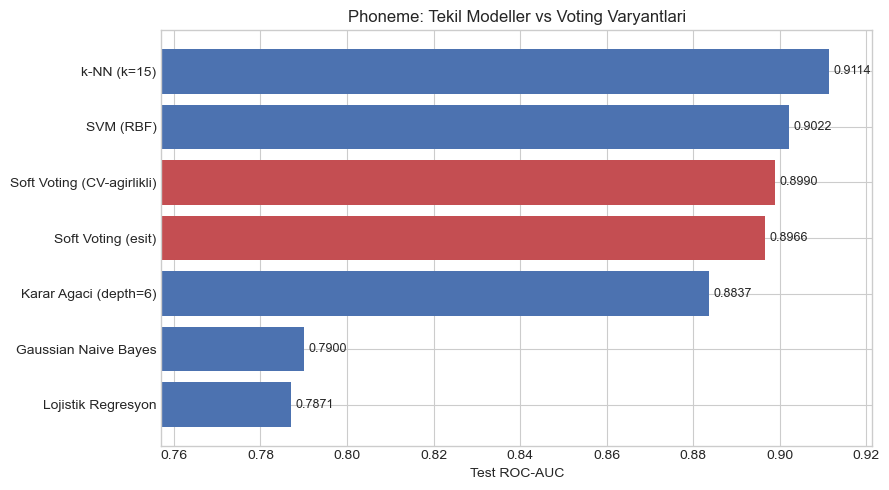

In [5]:
cv_ph = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_aucs_ph = {}
for name, model in estimators_ph:
    scores = cross_val_score(model, Xtr_ph_s, ytr_ph, cv=cv_ph, scoring='roc_auc')
    cv_aucs_ph[name] = scores.mean()

weights_ph = np.array([cv_aucs_ph[name] for name, _ in estimators_ph])
print("Katlama-ici CV ROC-AUC'ye gore agirliklar:")
for (name, _), w in zip(estimators_ph, weights_ph):
    print(f"  {display_names_ph[name]:<28} CV-AUC={cv_aucs_ph[name]:.4f}  agirlik={w:.4f}")

voting_weighted = VotingClassifier(estimators=estimators_ph, voting='soft', weights=weights_ph)
voting_weighted.fit(Xtr_ph_s, ytr_ph)
pred_weighted = voting_weighted.predict(Xte_ph_s)
proba_weighted = voting_weighted.predict_proba(Xte_ph_s)[:, 1]

print(f"\nEsit agirlikli soft voting  -> Accuracy={accuracy_score(yte_ph, pred_soft):.4f}, "
      f"ROC-AUC={roc_auc_score(yte_ph, proba_soft):.4f}")
print(f"CV-agirlikli soft voting    -> Accuracy={accuracy_score(yte_ph, pred_weighted):.4f}, "
      f"ROC-AUC={roc_auc_score(yte_ph, proba_weighted):.4f}")

plot_df_ph = pd.concat([
    baseline_ph[['ROC-AUC']],
    pd.DataFrame({'ROC-AUC': [roc_auc_score(yte_ph, proba_soft), roc_auc_score(yte_ph, proba_weighted)]},
                 index=['Soft Voting (esit)', 'Soft Voting (CV-agirlikli)']),
]).sort_values('ROC-AUC')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4c72b0' if 'Voting' not in idx else '#c44e52' for idx in plot_df_ph.index]
ax.barh(plot_df_ph.index, plot_df_ph['ROC-AUC'], color=colors)
ax.set_xlabel('Test ROC-AUC')
ax.set_title('Phoneme: Tekil Modeller vs Voting Varyantlari')
ax.set_xlim(plot_df_ph['ROC-AUC'].min() - 0.03, plot_df_ph['ROC-AUC'].max() + 0.01)
for i, v in enumerate(plot_df_ph['ROC-AUC']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Adım 5 · Model Çeşitliliği (Diversity) Analizi

§5'teki teoriyi somutlaştırıyoruz: beş taban modelin test setindeki **tahmin olasılıkları**
arasındaki Pearson korelasyonuna ve **hatalarının ne sıklıkla çakıştığına** bakıyoruz. Yüksek
korelasyon/çakışma, o çift modelin ensemble'a benzer bilgi kattığı (dolayısıyla düşük ek fayda
sağladığı) anlamına gelir; düşük korelasyon, birbirini tamamlayan hatalar yaptıkları (dolayısıyla
ensemble'a değerli çeşitlilik kattıkları) anlamına gelir.

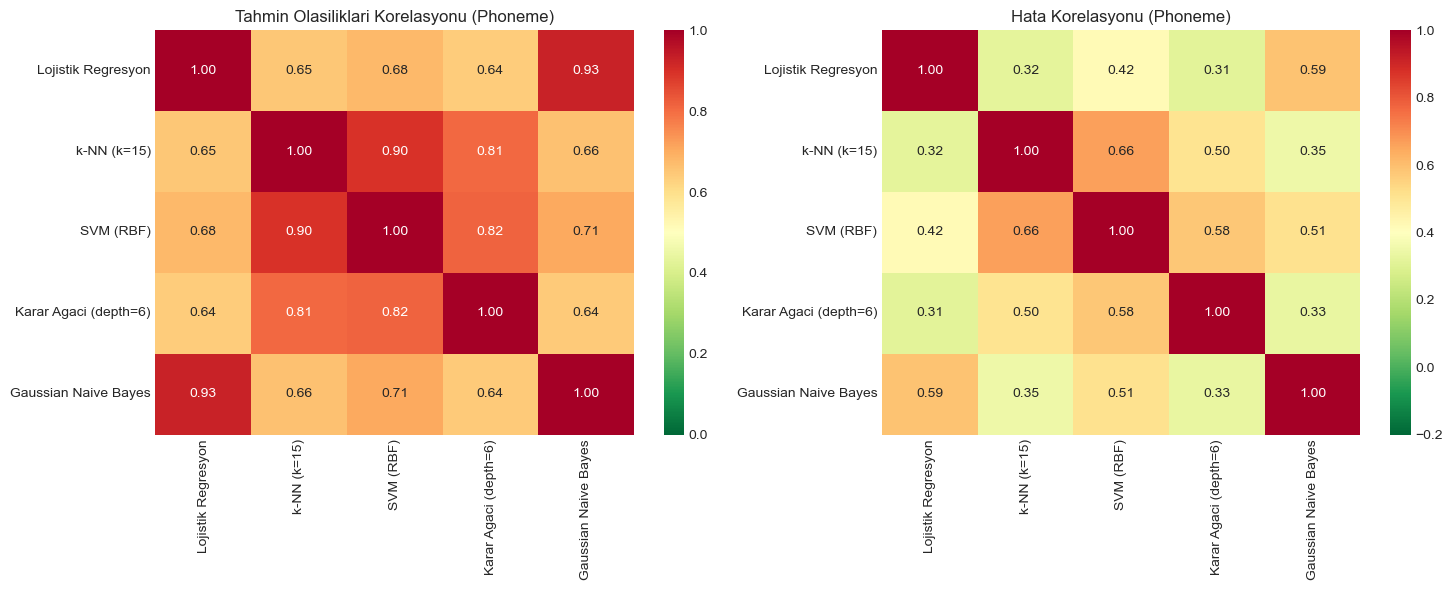

En DUSUK hata korelasyonlu (en 'cesitli') cift: ('Lojistik Regresyon', 'Karar Agaci (depth=6)') -> 0.312
En YUKSEK hata korelasyonlu (en 'benzer') cift: ('k-NN (k=15)', 'SVM (RBF)') -> 0.664

Her modelin digerleriyle ORTALAMA hata korelasyonu (dusuk = daha 'cesitli'):
Lojistik Regresyon       0.411
Karar Agaci (depth=6)    0.432
Gaussian Naive Bayes     0.444
k-NN (k=15)              0.458
SVM (RBF)                0.545
dtype: float64

YORUM: Lojistik Regresyon, digerleriyle ortalamada en DUSUK hata korelasyonuna sahip --
dogrusal bir karar siniri varsayimi, agac-tabanli ve cekirdek-tabanli modellerden en cok
ayrisan hatalari uretiyor. SVM (RBF) ise en YUKSEK ortalama korelasyona sahip --
k-NN ile ayni 'yerel benzerlik' mantigini paylastigi icin (SVM-RBF de ozunde bir cekirdek
agirlikli komsuluk olcumudur) hatalari k-NN'inkilerle sikca ortusuyor. Bu, ensemble'a model
EKLERKEN sadece dogrulugu degil, hangi 'aileden' oldugunu da dusunmenin (bkz. teori 5. bolum) neden
onemli oldugunu somu

In [6]:
proba_matrix_ph = pd.DataFrame({
    display_names_ph[name]: fitted_ph[name].predict_proba(Xte_ph_s)[:, 1]
    for name in fitted_ph
})
corr_ph = proba_matrix_ph.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(corr_ph, annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Tahmin Olasiliklari Korelasyonu (Phoneme)')

pred_matrix_ph = pd.DataFrame({
    display_names_ph[name]: fitted_ph[name].predict(Xte_ph_s) for name in fitted_ph
})
error_matrix_ph = pred_matrix_ph.apply(lambda col: (col != yte_ph.values).astype(int))
error_corr_ph = error_matrix_ph.corr()
sns.heatmap(error_corr_ph, annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=-0.2, vmax=1, ax=axes[1])
axes[1].set_title('Hata Korelasyonu (Phoneme)')
plt.tight_layout()
plt.show()

err_corr_no_diag = error_corr_ph.where(~np.eye(len(error_corr_ph), dtype=bool))
min_pair = err_corr_no_diag.stack().idxmin()
max_pair = err_corr_no_diag.stack().idxmax()
row_means = err_corr_no_diag.mean()
print(f"En DUSUK hata korelasyonlu (en 'cesitli') cift: {min_pair} -> {err_corr_no_diag.stack().min():.3f}")
print(f"En YUKSEK hata korelasyonlu (en 'benzer') cift: {max_pair} -> {err_corr_no_diag.stack().max():.3f}")
print("\nHer modelin digerleriyle ORTALAMA hata korelasyonu (dusuk = daha 'cesitli'):")
print(row_means.round(3).sort_values())
print(f"\nYORUM: {row_means.idxmin()}, digerleriyle ortalamada en DUSUK hata korelasyonuna sahip --")
print("dogrusal bir karar siniri varsayimi, agac-tabanli ve cekirdek-tabanli modellerden en cok")
print(f"ayrisan hatalari uretiyor. {row_means.idxmax()} ise en YUKSEK ortalama korelasyona sahip --")
print("k-NN ile ayni 'yerel benzerlik' mantigini paylastigi icin (SVM-RBF de ozunde bir cekirdek")
print("agirlikli komsuluk olcumudur) hatalari k-NN'inkilerle sikca ortusuyor. Bu, ensemble'a model")
print("EKLERKEN sadece dogrulugu degil, hangi 'aileden' oldugunu da dusunmenin (bkz. teori 5. bolum) neden")
print("onemli oldugunu somutlastiriyor.")

## Adım 6 · CreditCard Veri Seti — Klasik Bir Sızıntı Tuzağı ve Ön İşleme

**CreditCard** (Greene, *Econometric Analysis*; R'ın `AER` paketi — Kleiber & Zeileis, *Applied
Econometrics with R*), 1319 kredi kartı başvurusunun onaylanıp onaylanmadığını (`card`) 12
değişkenle (kredi geçmişi raporları, yaş, gelir, ev sahipliği, bağımlı sayısı, mevcut adreste
kalınan ay sayısı, vb.) tahmin etme problemidir. Veri setinde iki değişken — `expenditure` (aylık
kredi kartı harcaması) ve `share` (bu harcamanın gelire oranı) — **kart onaylanmadan sonra**
gözlemlenebilen miktarlardır: onaylanmayan bir başvuru için kredi kartı harcaması yapmak fiziksel
olarak imkansızdır. Bunu doğrudan veride kontrol edelim.

In [7]:
url_cc = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/AER/CreditCard.csv'
df_cc = pd.read_csv(url_cc).drop(columns=['rownames'])
df_cc['card_bin'] = (df_cc['card'] == 'yes').astype(int)

print(f"CreditCard veri seti boyutu: {df_cc.shape}")
print(df_cc['card'].value_counts())

leak_check = pd.crosstab(df_cc['card'], df_cc['expenditure'] == 0)
leak_check.columns = ['expenditure > 0', 'expenditure == 0']
print("\nSIZINTI KONTROLU -- card x (expenditure == 0):")
print(leak_check)
print(f"\nOnaylanmayan basvurularin yuzde kaci expenditure==0? "
      f"{(df_cc.loc[df_cc['card']=='no', 'expenditure']==0).mean():.1%}")
print("\nYORUM: 'card'=='no' olan basvurularin NEREDEYSE TAMAMINDA expenditure tam olarak sifir --")
print("bu degisken hedefin bir SONUCU, bir NEDENI degil. 'share' da expenditure'dan turetildigi")
print("icin ayni sizintiyi tasiyor. Gercekci bir ONAY-ONCESI model icin ikisini de disarida")
print("birakiyoruz -- aksi halde model, gelecekte bilinmeyecek bilgiyi 'gorerek' yapay derecede")
print("basarili gorunur (bkz. E4).")

CreditCard veri seti boyutu: (1319, 13)
card
yes    1023
no      296
Name: count, dtype: int64

SIZINTI KONTROLU -- card x (expenditure == 0):
      expenditure > 0  expenditure == 0
card                                   
no                  0               296
yes              1002                21

Onaylanmayan basvurularin yuzde kaci expenditure==0? 100.0%

YORUM: 'card'=='no' olan basvurularin NEREDEYSE TAMAMINDA expenditure tam olarak sifir --
bu degisken hedefin bir SONUCU, bir NEDENI degil. 'share' da expenditure'dan turetildigi
icin ayni sizintiyi tasiyor. Gercekci bir ONAY-ONCESI model icin ikisini de disarida
birakiyoruz -- aksi halde model, gelecekte bilinmeyecek bilgiyi 'gorerek' yapay derecede
basarili gorunur (bkz. E4).


In [8]:
FEATURES_CC = ['reports', 'age', 'income', 'owner', 'selfemp', 'dependents', 'months', 'majorcards', 'active']
NUM_CC = ['reports', 'age', 'income', 'dependents', 'months', 'majorcards', 'active']
CAT_CC = ['owner', 'selfemp']

X_cc = df_cc[FEATURES_CC]
y_cc = df_cc['card_bin']
Xtr_cc, Xte_cc, ytr_cc, yte_cc = train_test_split(
    X_cc, y_cc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cc
)

preprocess_cc = ColumnTransformer([
    ('num', StandardScaler(), NUM_CC),
    ('cat', OneHotEncoder(drop='if_binary'), CAT_CC),
])
Xtr_cc_t = preprocess_cc.fit_transform(Xtr_cc)
Xte_cc_t = preprocess_cc.transform(Xte_cc)

print(f"Egitim seti: {Xtr_cc.shape} -> islendikten sonra: {Xtr_cc_t.shape}")
print(f"Test seti:   {Xte_cc.shape} -> islendikten sonra: {Xte_cc_t.shape}")
print(f"Egitimde sinif dagilimi: {ytr_cc.mean():.3f} (onaylanma orani)")

Egitim seti: (1055, 9) -> islendikten sonra: (1055, 9)
Test seti:   (264, 9) -> islendikten sonra: (264, 9)
Egitimde sinif dagilimi: 0.775 (onaylanma orani)


## Adım 7 · Taban Modeller ve Manuel (Out-of-Fold) Stacking

Önce dört taban modeli (sızıntısız öznitelik setiyle) tek tek değerlendiriyoruz, sonra §3'teki
sızıntı tuzağını **elle** göstereceğiz: aynı meta-özellik tablosunu iki farklı şekilde üretip
(naif: taban modeli eğitim verisinde eğitip **aynı** veride tahmin ettirmek; doğru: `cross_val_predict`
ile out-of-fold tahmin üretmek) meta-modelin çapraz doğrulama skorunun ne kadar farklı çıktığını
karşılaştırıyoruz.

In [9]:
estimators_cc = [
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=25)),
    ('tree', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)),
]
display_names_cc = {
    'lr': 'Lojistik Regresyon', 'knn': 'k-NN (k=25)',
    'tree': 'Karar Agaci (depth=5)', 'rf': 'Random Forest (n=200)',
}

cc_rows = []
for name, model in estimators_cc:
    model.fit(Xtr_cc_t, ytr_cc)
    proba = model.predict_proba(Xte_cc_t)[:, 1]
    pred = model.predict(Xte_cc_t)
    cc_rows.append({
        'Model': display_names_cc[name],
        'Accuracy': accuracy_score(yte_cc, pred),
        'F1': f1_score(yte_cc, pred),
        'ROC-AUC': roc_auc_score(yte_cc, proba),
    })
baseline_cc = pd.DataFrame(cc_rows).set_index('Model').round(4).sort_values('ROC-AUC', ascending=False)
baseline_cc

,Accuracy,F1,ROC-AUC
Model,,,
Random Forest (n=200),0.8220,0.8939,0.8041
Lojistik Regresyon,0.8220,0.8944,0.7934
Karar Agaci (depth=5),0.8220,0.8939,0.7570
k-NN (k=25),0.8106,0.8899,0.7354


In [10]:
cv_cc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- NAIF (SIZDIRAN) YONTEM: taban modelleri TUM egitim setinde egit, AYNI sette tahmin uret ---
naive_meta_train = pd.DataFrame({
    name: model.fit(Xtr_cc_t, ytr_cc).predict_proba(Xtr_cc_t)[:, 1]
    for name, model in estimators_cc
})
meta_naive = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
naive_cv_auc = cross_val_score(meta_naive, naive_meta_train, ytr_cc, cv=cv_cc, scoring='roc_auc').mean()

# --- DOGRU YONTEM: out-of-fold (OOF) tahminler, cross_val_predict ile ---
oof_meta_train = pd.DataFrame(index=range(len(ytr_cc)))
for name, model in estimators_cc:
    oof_pred = cross_val_predict(model, Xtr_cc_t, ytr_cc, cv=cv_cc, method='predict_proba')[:, 1]
    oof_meta_train[name] = oof_pred

meta_oof = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
oof_cv_auc = cross_val_score(meta_oof, oof_meta_train, ytr_cc, cv=cv_cc, scoring='roc_auc').mean()

print(f"NAIF (sizdiran) stacking  -- meta-model CV ROC-AUC: {naive_cv_auc:.4f}")
print(f"DOGRU (OOF) stacking      -- meta-model CV ROC-AUC: {oof_cv_auc:.4f}")
print(f"Iyimser sapma: {naive_cv_auc - oof_cv_auc:+.4f} ({(naive_cv_auc/oof_cv_auc - 1):+.1%})")
print("\nYORUM: Naif yontem, taban modellerin kendi egitim verisi uzerindeki 'ezberlenmis'")
print("(asiri iyimser) tahminlerini meta-modele veriyor -- meta-model bu sahte guveni ogreniyor.")

# Nihai TEST degerlendirmesi: taban modelleri tum egitim setinde yeniden egit (zaten fit edilmis
# durumdalar), OOF ile egitilmis meta-modeli, tabanlarin TEST tahminleriyle degerlendir.
meta_oof.fit(oof_meta_train, ytr_cc)
test_meta_features = pd.DataFrame({name: model.predict_proba(Xte_cc_t)[:, 1] for name, model in estimators_cc})
test_meta_proba = meta_oof.predict_proba(test_meta_features)[:, 1]
manual_stack_test_auc = roc_auc_score(yte_cc, test_meta_proba)
print(f"\nManuel OOF stacking -- TEST ROC-AUC: {manual_stack_test_auc:.4f}")

NAIF (sizdiran) stacking  -- meta-model CV ROC-AUC: 0.9292
DOGRU (OOF) stacking      -- meta-model CV ROC-AUC: 0.8549
Iyimser sapma: +0.0743 (+8.7%)

YORUM: Naif yontem, taban modellerin kendi egitim verisi uzerindeki 'ezberlenmis'
(asiri iyimser) tahminlerini meta-modele veriyor -- meta-model bu sahte guveni ogreniyor.

Manuel OOF stacking -- TEST ROC-AUC: 0.8139


## Adım 8 · `StackingClassifier` (scikit-learn) ile Karşılaştırma

Aynı dört taban modeli ve aynı 5 katlamalı OOF stratejisini kullanan `StackingClassifier`'ı
kuruyoruz — Adım 7'deki elle yazılmış OOF stacking'in test ROC-AUC'sine ne kadar yakın çıktığını
doğruluyoruz. Ayrıca `passthrough=True` (orijinal öznitelikleri de meta-modele ekleme) seçeneğinin
etkisine bakıyoruz.

Manuel OOF stacking ile sklearn StackingClassifier (passthrough=False) TEST ROC-AUC farki: 0.0000 -- neredeyse ozdes, ayni OOF mantigini
dogru uyguladigimizi dogruluyor.

YORUM: passthrough=True (0.8012), passthrough=False'tan (0.8139) DAHA
KOTU -- bu veri setinde orijinal 9 ozniteligi meta-modele eklemek fayda saglamiyor, aksine
meta-modelin (Lojistik Regresyon, sadece 1055 satir) etkin boyutunu artirip hafifce asiri
ogrenmesine yol aciyor olabilir. 'passthrough=True her zaman daha iyidir' varsayimi burada
dogrulanmiyor -- dogru ayari veri setine gore deneyerek bulmak gerekiyor.


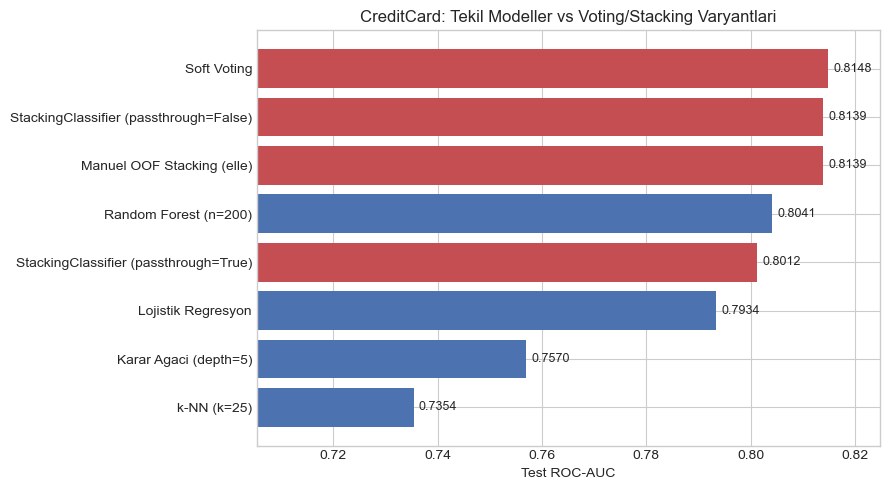

,TEST ROC-AUC
Yontem,
Soft Voting,0.8148
Manuel OOF Stacking (elle),0.8139
StackingClassifier (passthrough=False),0.8139
Random Forest (n=200),0.8041
StackingClassifier (passthrough=True),0.8012
Lojistik Regresyon,0.7934
Karar Agaci (depth=5),0.7570
k-NN (k=25),0.7354


In [11]:
stack_cc = StackingClassifier(
    estimators=estimators_cc,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=cv_cc, passthrough=False,
)
stack_cc.fit(Xtr_cc_t, ytr_cc)
sk_stack_proba = stack_cc.predict_proba(Xte_cc_t)[:, 1]
sk_stack_auc = roc_auc_score(yte_cc, sk_stack_proba)

stack_cc_pt = StackingClassifier(
    estimators=estimators_cc,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=cv_cc, passthrough=True,
)
stack_cc_pt.fit(Xtr_cc_t, ytr_cc)
sk_stack_pt_auc = roc_auc_score(yte_cc, stack_cc_pt.predict_proba(Xte_cc_t)[:, 1])

# CreditCard icin soft voting de ekleyelim (dogrudan karsilastirma icin)
voting_cc = VotingClassifier(estimators=estimators_cc, voting='soft')
voting_cc.fit(Xtr_cc_t, ytr_cc)
voting_cc_auc = roc_auc_score(yte_cc, voting_cc.predict_proba(Xte_cc_t)[:, 1])

summary_rows_cc = [
    {'Yontem': 'Soft Voting', 'TEST ROC-AUC': voting_cc_auc},
    {'Yontem': 'Manuel OOF Stacking (elle)', 'TEST ROC-AUC': manual_stack_test_auc},
    {'Yontem': 'StackingClassifier (passthrough=False)', 'TEST ROC-AUC': sk_stack_auc},
    {'Yontem': 'StackingClassifier (passthrough=True)', 'TEST ROC-AUC': sk_stack_pt_auc},
]
summary_cc = pd.concat([
    baseline_cc.reset_index().rename(columns={'Model': 'Yontem', 'ROC-AUC': 'TEST ROC-AUC'})[['Yontem', 'TEST ROC-AUC']],
    pd.DataFrame(summary_rows_cc),
]).set_index('Yontem').round(4).sort_values('TEST ROC-AUC', ascending=False)
print(f"Manuel OOF stacking ile sklearn StackingClassifier (passthrough=False) TEST ROC-AUC farki: "
      f"{abs(manual_stack_test_auc - sk_stack_auc):.4f} -- neredeyse ozdes, ayni OOF mantigini")
print("dogru uyguladigimizi dogruluyor.")
if sk_stack_pt_auc < sk_stack_auc:
    print(f"\nYORUM: passthrough=True ({sk_stack_pt_auc:.4f}), passthrough=False'tan ({sk_stack_auc:.4f}) DAHA")
    print("KOTU -- bu veri setinde orijinal 9 ozniteligi meta-modele eklemek fayda saglamiyor, aksine")
    print("meta-modelin (Lojistik Regresyon, sadece 1055 satir) etkin boyutunu artirip hafifce asiri")
    print("ogrenmesine yol aciyor olabilir. 'passthrough=True her zaman daha iyidir' varsayimi burada")
    print("dogrulanmiyor -- dogru ayari veri setine gore deneyerek bulmak gerekiyor.")

fig, ax = plt.subplots(figsize=(9, 5))
plot_cc = summary_cc.sort_values('TEST ROC-AUC')
colors_cc = ['#c44e52' if ('Voting' in i or 'Stacking' in i) else '#4c72b0' for i in plot_cc.index]
ax.barh(plot_cc.index, plot_cc['TEST ROC-AUC'], color=colors_cc)
ax.set_xlabel('Test ROC-AUC')
ax.set_title('CreditCard: Tekil Modeller vs Voting/Stacking Varyantlari')
ax.set_xlim(plot_cc['TEST ROC-AUC'].min() - 0.03, plot_cc['TEST ROC-AUC'].max() + 0.01)
for i, v in enumerate(plot_cc['TEST ROC-AUC']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

summary_cc

## Adım 9 · Beijing PM2.5 Veri Seti — Yükleme ve Ön İşleme (Regresyon)

**Beijing PM2.5 Data** (Liang, X. ve ark. 2015, "Assessing Beijing's PM2.5 pollution: severity,
weather impact, APEC and winter heating", *Proceedings of the Royal Society A*, UCI Machine
Learning Repository), 2010-2014 arası saatlik hava kirliliği (PM2.5, µg/m³) ve meteorolojik
ölçümleri içerir. Hedefimiz, **hava durumu değişkenlerinden PM2.5 seviyesini tahmin etmek** —
gerçek bir kamu sağlığı/çevre izleme senaryosu (yüksek PM2.5 uyarı sistemleri, hava kalitesi
tahmin panoları). Hedef değişkende (`pm2.5`) eksik satırları çıkarıyoruz; rüzgar yönü (`cbwd`)
kategorik olduğu için one-hot encode ediyoruz, `month` da mevsimsel etkiyi (makalenin vurguladığı
kış-ısıtması etkisi) yakalamak için özniteliklere dahil ediliyor.

In [12]:
url_pol = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv'
df_pol = pd.read_csv(url_pol)
print(f"Ham veri boyutu: {df_pol.shape}")
print(f"Hedefte (pm2.5) eksik deger sayisi: {df_pol['pm2.5'].isna().sum()}")

df_pol = df_pol.dropna(subset=['pm2.5']).reset_index(drop=True)
print(f"Hedef eksikleri cikarildiktan sonra: {df_pol.shape}")

FEATURES_POL = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd', 'month']
NUM_POL = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'month']

X_pol = pd.get_dummies(df_pol[FEATURES_POL], columns=['cbwd'], drop_first=True)
y_pol = df_pol['pm2.5']

print(f"\nHedef degisken (PM2.5, ug/m3) istatistikleri:")
print(y_pol.describe().round(1))

Xtr_pol, Xte_pol, ytr_pol, yte_pol = train_test_split(X_pol, y_pol, test_size=0.2, random_state=RANDOM_STATE)

scaler_pol = StandardScaler()
Xtr_pol_s = Xtr_pol.copy()
Xte_pol_s = Xte_pol.copy()
Xtr_pol_s[NUM_POL] = scaler_pol.fit_transform(Xtr_pol[NUM_POL])
Xte_pol_s[NUM_POL] = scaler_pol.transform(Xte_pol[NUM_POL])

print(f"\nEgitim: {Xtr_pol_s.shape}, Test: {Xte_pol_s.shape}")

Ham veri boyutu: (43824, 13)
Hedefte (pm2.5) eksik deger sayisi: 2067
Hedef eksikleri cikarildiktan sonra: (41757, 13)

Hedef degisken (PM2.5, ug/m3) istatistikleri:
count    41757.0
mean        98.6
std         92.1
min          0.0
25%         29.0
50%         72.0
75%        137.0
max        994.0
Name: pm2.5, dtype: float64

Egitim: (33405, 10), Test: (8352, 10)


## Adım 10 · `VotingRegressor`

Sınıflandırmadaki mantığın regresyon karşılığı: `VotingRegressor`, taban regresörlerin
tahminlerinin **ağırlıklı ortalamasını** alır (varsayılan: eşit ağırlık). Dört farklı algoritma
ailesinden taban model kullanıyoruz: Ridge (doğrusal, düzenlileştirilmiş), k-NN, Karar Ağacı,
Random Forest.

In [13]:
estimators_pol = [
    ('ridge', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ('knn', KNeighborsRegressor(n_neighbors=15)),
    ('tree', DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)),
]
display_names_pol = {
    'ridge': 'Ridge Regresyon', 'knn': 'k-NN (k=15)',
    'tree': 'Karar Agaci (depth=8)', 'rf': 'Random Forest (n=200)',
}

reg_rows = []
fitted_pol = {}
for name, model in estimators_pol:
    model.fit(Xtr_pol_s, ytr_pol)
    fitted_pol[name] = model
    pred = model.predict(Xte_pol_s)
    reg_rows.append({
        'Model': display_names_pol[name],
        'RMSE': rmse(yte_pol, pred),
        'MAE': mean_absolute_error(yte_pol, pred),
        'R2': r2_score(yte_pol, pred),
    })

voting_reg = VotingRegressor(estimators=estimators_pol)
voting_reg.fit(Xtr_pol_s, ytr_pol)
pred_vr = voting_reg.predict(Xte_pol_s)
reg_rows.append({
    'Model': 'Voting Regressor (esit agirlik)',
    'RMSE': rmse(yte_pol, pred_vr), 'MAE': mean_absolute_error(yte_pol, pred_vr), 'R2': r2_score(yte_pol, pred_vr),
})

reg_baseline_pol = pd.DataFrame(reg_rows).set_index('Model').round(3).sort_values('RMSE')
reg_baseline_pol

,RMSE,MAE,R2
Model,,,
Random Forest (n=200),60.113,39.533,0.590
k-NN (k=15),63.539,41.991,0.542
Voting Regressor (esit agirlik),64.196,43.640,0.532
Karar Agaci (depth=8),70.002,47.532,0.444
Ridge Regresyon,81.038,57.445,0.255


## Adım 11 · `StackingRegressor` ve Blending Karşılaştırması

Aynı dört taban regresörle iki farklı meta-öğrenme stratejisini karşılaştırıyoruz:

1. **`StackingRegressor`** (sklearn) — §3'teki OOF mantığını `cv=5` ile otomatik uygular, meta-model
   olarak basit bir Ridge regresyon kullanır.
2. **Blending** (§4) — eğitim setini taban-eğitim (%75) ve holdout (%25) olarak ikiye bölüyoruz,
   taban modelleri SADECE taban-eğitim kısmında eğitiyoruz, holdout üzerindeki tahminleriyle
   meta-modeli eğitiyoruz. Blending'de taban modellerin daha az veriyle eğitildiğine (dolayısıyla
   biraz daha zayıf olabileceğine) dikkat edin — bu, §4'teki "blending veri-verimliliği açısından
   stacking'den geride kalabilir" teorik noktasının somut örneği.

Blending -- taban-egitim: (25053, 10), holdout: (8352, 10)


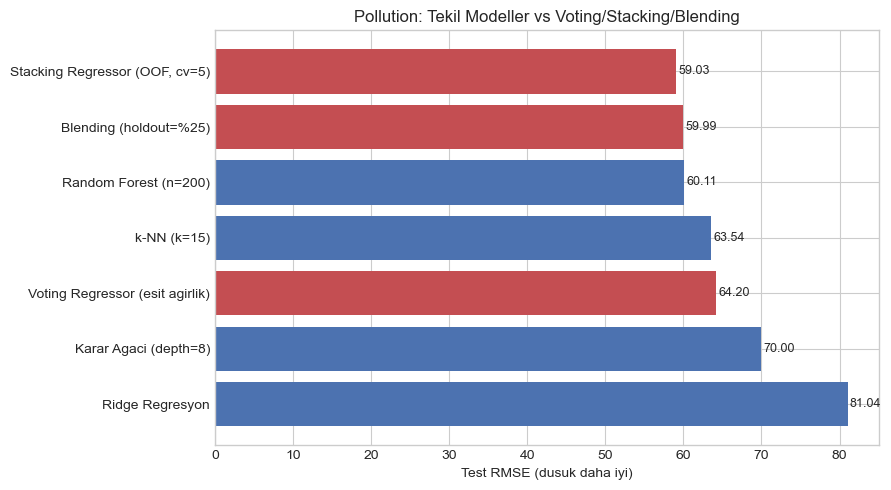

,RMSE,MAE,R2
Model,,,
"Stacking Regressor (OOF, cv=5)",59.034,38.495,0.604
Blending (holdout=%25),59.994,39.288,0.592
Random Forest (n=200),60.113,39.533,0.590
k-NN (k=15),63.539,41.991,0.542
Voting Regressor (esit agirlik),64.196,43.640,0.532
Karar Agaci (depth=8),70.002,47.532,0.444
Ridge Regresyon,81.038,57.445,0.255


In [14]:
cv_pol = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
stack_reg = StackingRegressor(estimators=estimators_pol, final_estimator=Ridge(alpha=1.0), cv=cv_pol)
stack_reg.fit(Xtr_pol_s, ytr_pol)
pred_sr = stack_reg.predict(Xte_pol_s)
stack_reg_metrics = {'RMSE': rmse(yte_pol, pred_sr), 'MAE': mean_absolute_error(yte_pol, pred_sr), 'R2': r2_score(yte_pol, pred_sr)}

# --- Blending: taban-egitim / holdout ayrimi ---
Xtr_pol_base, Xtr_pol_hold, ytr_pol_base, ytr_pol_hold = train_test_split(
    Xtr_pol_s, ytr_pol, test_size=0.25, random_state=RANDOM_STATE
)
print(f"Blending -- taban-egitim: {Xtr_pol_base.shape}, holdout: {Xtr_pol_hold.shape}")

blend_meta_train = pd.DataFrame(index=range(len(ytr_pol_hold)))
blend_base_models = {}
for name, model_template in estimators_pol:
    model = type(model_template)(**model_template.get_params())
    model.fit(Xtr_pol_base, ytr_pol_base)
    blend_base_models[name] = model
    blend_meta_train[name] = model.predict(Xtr_pol_hold)

meta_blend = Ridge(alpha=1.0)
meta_blend.fit(blend_meta_train, ytr_pol_hold)

blend_test_features = pd.DataFrame({name: blend_base_models[name].predict(Xte_pol_s) for name in blend_base_models})
pred_blend = meta_blend.predict(blend_test_features)
blend_metrics = {'RMSE': rmse(yte_pol, pred_blend), 'MAE': mean_absolute_error(yte_pol, pred_blend), 'R2': r2_score(yte_pol, pred_blend)}

reg_rows2 = [
    {'Model': 'Stacking Regressor (OOF, cv=5)', **stack_reg_metrics},
    {'Model': 'Blending (holdout=%25)', **blend_metrics},
]
final_reg_comparison = pd.concat([reg_baseline_pol, pd.DataFrame(reg_rows2).set_index('Model').round(3)])
final_reg_comparison = final_reg_comparison.round(3).sort_values('RMSE', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_pol = ['#c44e52' if ('Voting' in i or 'Stacking' in i or 'Blending' in i) else '#4c72b0'
              for i in final_reg_comparison.index]
ax.barh(final_reg_comparison.index, final_reg_comparison['RMSE'], color=colors_pol)
ax.set_xlabel('Test RMSE (dusuk daha iyi)')
ax.set_title('Pollution: Tekil Modeller vs Voting/Stacking/Blending')
for i, v in enumerate(final_reg_comparison['RMSE']):
    ax.text(v + 0.3, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

final_reg_comparison.sort_values('RMSE')

## Adım 12 · Sentez — Üç Problem İçin Karşılaştırmalı Özet ve Karar Rehberi

Üç ayrı problemde (Phoneme sınıflandırma, CreditCard sınıflandırma, Pollution regresyon) en iyi
tekil modeli en iyi ensemble yöntemiyle karşılaştırıp, ensemble'ın sağladığı **göreli iyileşmeyi**
özetliyoruz.

In [15]:
def rel_improvement(best_single, best_ensemble, higher_is_better=True):
    if higher_is_better:
        return (best_ensemble - best_single) / best_single
    return (best_single - best_ensemble) / best_single


synthesis_rows = [
    {
        'Problem': 'Phoneme (siniflandirma)',
        'En iyi tekil model': f"{baseline_ph['ROC-AUC'].idxmax()} ({baseline_ph['ROC-AUC'].max():.4f} AUC)",
        'En iyi ensemble': f"CV-agirlikli Soft Voting ({roc_auc_score(yte_ph, proba_weighted):.4f} AUC)",
        'Goreli iyilesme': f"{rel_improvement(baseline_ph['ROC-AUC'].max(), roc_auc_score(yte_ph, proba_weighted)):+.2%}",
    },
    {
        'Problem': 'CreditCard (siniflandirma)',
        'En iyi tekil model': f"{baseline_cc['ROC-AUC'].idxmax()} ({baseline_cc['ROC-AUC'].max():.4f} AUC)",
        'En iyi ensemble': f"En iyi stacking varyanti ({summary_cc['TEST ROC-AUC'].max():.4f} AUC)",
        'Goreli iyilesme': f"{rel_improvement(baseline_cc['ROC-AUC'].max(), summary_cc['TEST ROC-AUC'].max()):+.2%}",
    },
    {
        'Problem': 'Pollution (regresyon)',
        'En iyi tekil model': f"{reg_baseline_pol['RMSE'].idxmin()} ({reg_baseline_pol['RMSE'].min():.2f} RMSE)",
        'En iyi ensemble': f"{final_reg_comparison['RMSE'].idxmin()} ({final_reg_comparison['RMSE'].min():.2f} RMSE)",
        'Goreli iyilesme': f"{rel_improvement(reg_baseline_pol['RMSE'].min(), final_reg_comparison['RMSE'].min(), higher_is_better=False):+.2%}",
    },
]
pd.DataFrame(synthesis_rows).set_index('Problem')

,En iyi tekil model,En iyi ensemble,Goreli iyilesme
Problem,,,
Phoneme (siniflandirma),k-NN (k=15) (0.9114 AUC),CV-agirlikli Soft Voting (0.8990 AUC),-1.36%
CreditCard (siniflandirma),Random Forest (n=200) (0.8041 AUC),En iyi stacking varyanti (0.8148 AUC),+1.33%
Pollution (regresyon),Random Forest (n=200) (60.11 RMSE),"Stacking Regressor (OOF, cv=5) (59.03 RMSE)",+1.79%


| Koşul | Yöntem | Not |
|---|---|---|
| Hız/basitlik öncelikli, taban modeller zaten `predict_proba` veriyor | **Soft Voting** | Ek eğitim gerektirmez, sadece tahmin zamanında ortalama alır |
| Modellerin çoğu iyi, olasılık çıktısı yok/güvenilmez | **Hard Voting** | Basit ama olasılık-tabanlı metrikler (ROC-AUC, kalibrasyon) için kullanılamaz |
| Taban modellerin **güvenilirliği farklı**, geçmiş performans bilgisi var | **Ağırlıklı Voting** | Ağırlıkları veri sızıntısı olmadan (ör. CV skoruyla) belirleyin |
| Veri orta/küçük boyutlu, her örneğin katkısı önemli, hesaplama bütçesi yeterli | **Stacking (OOF, `cv` ile)** | `StackingClassifier`/`Regressor` OOF disiplinini otomatik uygular — elle yazmaya gerek yok, ama nasıl çalıştığını bilmek hata ayıklamada kritik |
| Veri çok büyük veya zaman baskısı var, $K$-kat stacking çok pahalı | **Blending** | Holdout payı taban modellerden "çalınır" — veri kısıtlıyken stacking'den geride kalabilir (bkz. Adım 11) |
| Gerçek-zamanlı/düşük-gecikmeli production, yorumlanabilirlik zorunlu (ör. kredi red gerekçesi) | **Tekil model** (mümkünse doğrusal) | Ensemble'ın maliyeti (gecikme + açıklanabilirlik kaybı) faydasından yüksek olabilir, bkz. §6 |

# 📊 R Uygulaması

Bu notebook'ta R bölümü kısa tutuldu (proje kararı, 2026-09-08): ana teknik derinlik Python
tarafında; burada sadece R ekosisteminin bu konuya doğrudan karşılığını (`caretEnsemble` paketi)
ve paket kullanmadan en basit haliyle soft voting'i, Phoneme veri setinde gösteriyoruz.
`caretEnsemble`, `caretList` ile birden fazla `caret` modelini **aynı yeniden örnekleme
indeksleriyle** eğitip `caretStack`/`caretEnsemble` ile birleştirir — sklearn'ün
`StackingClassifier`'ının R'daki en doğrudan karşılığıdır.

In [16]:
%load_ext rpy2.ipython

In [17]:
df_phoneme_r = df_ph.copy()
print(df_phoneme_r.shape)

(5404, 6)


In [18]:
%%R
# Çoklu çekirdek yönetimini devre dışı bırakın
options(cores = 1)
if (requireNamespace("parallel", quietly = TRUE)) {
  options(mc.cores = 1)
}


### R 1 · `caret` + `caretEnsemble` ile Stacking (Phoneme)

In [ ]:
%%R -i df_phoneme_r
suppressMessages({
  library(caret)
  library(caretEnsemble)
  library(pROC)
})

# Çoklu çekirdek yönetimini devre dışı bırakın
options(cores = 1)
options(mc.cores = 1)
if (data.table::getDTthreads() > 1) data.table::setDTthreads(1)



df_phoneme_r$target <- factor(ifelse(df_phoneme_r$target == 1, "Oral", "Nasal"))

set.seed(42)
train_idx <- createDataPartition(df_phoneme_r$target, p = 0.8, list = FALSE)
train_r <- df_phoneme_r[train_idx, ]
test_r  <- df_phoneme_r[-train_idx, ]

folds <- createFolds(train_r$target, k = 5, returnTrain = TRUE)
ctrl <- trainControl(method = "cv", number = 5, index = folds, 
                     savePredictions = "final", classProbs = TRUE, 
                     summaryFunction = twoClassSummary)

model_list <- caretList(
  target ~ ., data = train_r, trControl = ctrl, metric = "ROC",
  methodList = c("glm", "knn", "rpart")
)

stack_r <- caretStack(
  model_list, method = "glm", metric = "ROC",
  trControl = trainControl(method = "cv", number = 5, 
                           classProbs = TRUE, summaryFunction = twoClassSummary)
)

# Taban modellerin test verisi üzerindeki olasılık tahminlerini elle matrisleştiriyoruz
# caretStack'in arka planda yaptığı bu işlemi doğrudan vererek predict bug'ını bypass ediyoruz
base_preds <- lapply(model_list, function(m) {
  predict(m, newdata = test_r, type = "prob")[, "Oral"]
})
base_preds_df <- as.data.frame(base_preds)
colnames(base_preds_df) <- names(model_list)

# Meta model olan glm'i bu yeni veri çerçevesi üzerinde çalıştırıp test olasılıklarını alıyoruz
pred_probs_r <- predict(stack_r$ens_model, newdata = base_preds_df, type = "prob")

# pROC fonksiyonuna vaka (Oral) sınıfının sayısal olasılıklarını gönderiyoruz
roc_obj <- roc(response = test_r$target, 
               predictor = pred_probs_r[, "Oral"], 
               levels = c("Nasal", "Oral"),
               quiet = TRUE)

auc_val_r <- auc(roc_obj)
cat("\nTEST AUC:", round(auc_val_r, 4), "\n")



TEST AUC: 0.9203 


### R 2 · Paket Olmadan Basit Soft Voting

`caretEnsemble` olmadan, en temel haliyle soft voting: iki modelin (`glm` ve `knn`) olasılık
tahminlerinin basit ortalaması, §2'deki soft voting formülünün en yalın R karşılığı.

In [24]:
%%R
glm_fit <- glm(target ~ ., data = train_r, family = binomial)
prob_glm <- predict(glm_fit, newdata = test_r, type = "response")

library(class)
train_x <- train_r[, setdiff(names(train_r), "target")]
test_x  <- test_r[, setdiff(names(test_r), "target")]
knn_pred <- knn(train_x, test_x, cl = train_r$target, k = 15, prob = TRUE)
prob_knn_oral <- ifelse(knn_pred == "Oral", attr(knn_pred, "prob"), 1 - attr(knn_pred, "prob"))

# glm'de "Oral" pozitif sinif mi kontrol edip olasiligi hizalayalim
prob_glm_oral <- if (levels(train_r$target)[2] == "Oral") prob_glm else 1 - prob_glm

soft_vote_prob <- (prob_glm_oral + prob_knn_oral) / 2
soft_vote_class <- ifelse(soft_vote_prob > 0.5, "Oral", "Nasal")
cat("Basit (paketsiz) soft voting dogruluk:", round(mean(soft_vote_class == test_r$target), 4), "\n")

Basit (paketsiz) soft voting dogruluk: 0.8426 


# 🗄️ SQL Uygulaması (DuckDB)

SQL bölümü de bu notebook'ta kısa tutuldu: soft voting ve ağırlıklı voting'in aslında birer
`AVG`/`SUM` sorgusundan ibaret olduğunu, DuckDB'de taban modellerin olasılık çıktılarını
yeniden üreterek gösteriyoruz — sklearn'ün `VotingClassifier`'ıyla makine hassasiyetinde eşleşme
bekliyoruz.

In [25]:
import duckdb
con = duckdb.connect()

### SQL 1 · Soft Voting'in SQL'de Yeniden Üretilmesi (Phoneme)

In [26]:
sql_probs_ph = pd.DataFrame({name: fitted_ph[name].predict_proba(Xte_ph_s)[:, 1] for name in fitted_ph})
sql_probs_ph['y_true'] = yte_ph.values
con.register('probs_ph', sql_probs_ph)

query_soft = '''
    SELECT
        y_true,
        (lr + knn + svm + tree + nb) / 5.0 AS avg_proba,
        CASE WHEN (lr + knn + svm + tree + nb) / 5.0 > 0.5 THEN 1 ELSE 0 END AS sql_soft_vote
    FROM probs_ph
'''
sql_result_ph = con.execute(query_soft).df()

sql_acc = (sql_result_ph['sql_soft_vote'] == sql_result_ph['y_true']).mean()
sklearn_acc = accuracy_score(yte_ph, pred_soft)
print(f"SQL ile yeniden uretilen soft voting dogrulugu:    {sql_acc:.6f}")
print(f"sklearn VotingClassifier(voting='soft') dogrulugu: {sklearn_acc:.6f}")
print(f"Fark: {abs(sql_acc - sklearn_acc):.10f}")

SQL ile yeniden uretilen soft voting dogrulugu:    0.830712
sklearn VotingClassifier(voting='soft') dogrulugu: 0.830712
Fark: 0.0000000000


### SQL 2 · Ağırlıklı Oylamanın SQL'de Yeniden Üretilmesi (Phoneme)

Bu kez model isim/ağırlık çiftlerini ayrı bir tabloya (`weights_tbl`) koyup, olasılık tablosunu
uzun formata çevirip (`melt`) bir `JOIN` + `GROUP BY` ile ağırlıklı ortalamayı hesaplıyoruz —
Adım 4'teki `VotingClassifier(weights=...)` mantığının SQL karşılığı.

In [27]:
weights_df_ph = pd.DataFrame({'model': [n for n, _ in estimators_ph], 'weight': weights_ph})
con.register('weights_tbl', weights_df_ph)

probs_long_ph = (
    sql_probs_ph.drop(columns='y_true').reset_index()
    .melt(id_vars='index', var_name='model', value_name='proba')
)
con.register('probs_long_ph', probs_long_ph)

query_weighted = '''
    SELECT p."index" AS row_id,
           SUM(p.proba * w.weight) / SUM(w.weight) AS weighted_proba
    FROM probs_long_ph p
    JOIN weights_tbl w ON p.model = w.model
    GROUP BY p."index"
    ORDER BY p."index"
'''
sql_weighted = con.execute(query_weighted).df()
sql_weighted_class = (sql_weighted['weighted_proba'] > 0.5).astype(int)
sql_weighted_acc = (sql_weighted_class.values == yte_ph.values).mean()
sklearn_weighted_acc = accuracy_score(yte_ph, pred_weighted)

print(f"SQL agirlikli oylama dogrulugu:              {sql_weighted_acc:.6f}")
print(f"sklearn agirlikli VotingClassifier dogrulugu: {sklearn_weighted_acc:.6f}")
print(f"Fark: {abs(sql_weighted_acc - sklearn_weighted_acc):.10f}")

SQL agirlikli oylama dogrulugu:              0.836263
sklearn agirlikli VotingClassifier dogrulugu: 0.836263
Fark: 0.0000000000


## ✏️ Egzersizler

Aşağıdaki egzersizler bu notebook'ta zaten yüklü olan `Xtr_ph_s`/`ytr_ph`, `Xtr_cc_t`/`ytr_cc`,
`Xtr_pol_s`/`ytr_pol` (ve ilgili `estimators_*` listeleri) üzerine kurulu — çözmeden önce ilgili
hücreleri çalıştırmış olmanız yeterli.

**E1.** Phoneme veri setinde `estimators_ph` listesine bir altıncı taban model olarak
`RandomForestClassifier` ekleyin. Hard voting ve soft voting sonuçları nasıl değişiyor? Adım 5'teki
hata korelasyon matrisine göre, Random Forest'ın en çok hangi modelle "benzer" hata yaptığını
tahmin edebilir misiniz — sonucu doğrulayın.

In [28]:
print("\n==== Egzersiz 1: Altı Modelli Ensemble ====")

estimators_ph_max = [
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=15)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ('tree', DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
    ('nb', GaussianNB()),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
]
display_names_ph_max = {
    'lr': 'Lojistik Regresyon', 'knn': 'k-NN (k=15)', 'svm': 'SVM (RBF)',
    'tree': 'Karar Agaci (depth=6)', 'nb': 'Gaussian Naive Bayes',
    'rf':'Random Forest (n=200)'
}
fitted_ph = {}
rows = []
for name, model in estimators_ph_max:
    model.fit(Xtr_ph_s, ytr_ph)
    fitted_ph[name] = model
    pred = model.predict(Xte_ph_s)
    proba = model.predict_proba(Xte_ph_s)[:, 1]
    rows.append({
        'Model': display_names_ph_max[name],
        'Accuracy': accuracy_score(yte_ph, pred),
        'F1': f1_score(yte_ph, pred),
        'ROC-AUC': roc_auc_score(yte_ph, proba),
    })
baseline_ph_max = pd.DataFrame(rows).set_index('Model').round(4).sort_values('ROC-AUC', ascending=False)
baseline_ph_max


==== Egzersiz 1: Altı Modelli Ensemble ====


,Accuracy,F1,ROC-AUC
Model,,,
Random Forest (n=200),0.8955,0.8169,0.9505
k-NN (k=15),0.8427,0.7240,0.9114
SVM (RBF),0.8326,0.7104,0.9022
Karar Agaci (depth=6),0.8427,0.7276,0.8837
Gaussian Naive Bayes,0.7447,0.6156,0.7900
Lojistik Regresyon,0.7364,0.4865,0.7871


In [29]:
voting_hard_max = VotingClassifier(estimators=estimators_ph_max, voting='hard')
voting_hard_max.fit(Xtr_ph_s, ytr_ph)
pred_hard = voting_hard_max.predict(Xte_ph_s)

voting_soft_max = VotingClassifier(estimators=estimators_ph_max, voting='soft')
voting_soft_max.fit(Xtr_ph_s, ytr_ph)
pred_soft = voting_soft_max.predict(Xte_ph_s)
proba_soft = voting_soft_max.predict_proba(Xte_ph_s)[:, 1]

voting_rows = [
    {'Model': 'Hard Voting (6 model)', 'Accuracy': accuracy_score(yte_ph, pred_hard),
     'F1': f1_score(yte_ph, pred_hard), 'ROC-AUC': np.nan},
    {'Model': 'Soft Voting (6 model, esit agirlik)', 'Accuracy': accuracy_score(yte_ph, pred_soft),
     'F1': f1_score(yte_ph, pred_soft), 'ROC-AUC': roc_auc_score(yte_ph, proba_soft)},
]
voting_df_ph_max = pd.DataFrame(voting_rows).set_index('Model').round(4)
comparison_ph_max = pd.concat([baseline_ph_max, voting_df_ph_max])

best_single_acc = baseline_ph_max['Accuracy'].max()
print(f"En iyi tek model dogrulugu: {best_single_acc:.4f}")
print(f"Soft voting dogrulugu:      {accuracy_score(yte_ph, pred_soft):.4f}")
print(f"Hard voting dogrulugu:      {accuracy_score(yte_ph, pred_hard):.4f}")
comparison_ph

En iyi tek model dogrulugu: 0.8955
Soft voting dogrulugu:      0.8501
Hard voting dogrulugu:      0.8538


,Accuracy,F1,ROC-AUC
Model,,,
k-NN (k=15),0.8427,0.7240,0.9114
SVM (RBF),0.8326,0.7104,0.9022
Karar Agaci (depth=6),0.8427,0.7276,0.8837
Gaussian Naive Bayes,0.7447,0.6156,0.7900
Lojistik Regresyon,0.7364,0.4865,0.7871
Hard Voting (5 model),0.8409,0.7261,NaN
"Soft Voting (5 model, esit agirlik)",0.8307,0.7154,0.8966


**E2.** Adım 4'teki ağırlıklı oylamada, ağırlıkları CV ROC-AUC yerine CV **F1** skoruna göre
belirleyin (`scoring='f1'`). Sonuçlanan ağırlıklar ve nihai Accuracy/ROC-AUC, AUC-tabanlı
ağırlıklandırmadan farklı mı çıkıyor?

In [33]:
print("\n==== Egzersiz 2: CV-Metric Skoruna Göre Ağırlıklı Soft Voting ====")
cv_ph = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1_ph = {}
for name, model in estimators_ph:
    scores = cross_val_score(model, Xtr_ph_s, ytr_ph, cv=cv_ph, scoring='f1')
    cv_f1_ph[name] = scores.mean()

weights_ph_f1 = np.array([cv_f1_ph[name] for name, _ in estimators_ph])
print("Katlama-ici CV F1'ye gore agirliklar:")
for (name, _), w in zip(estimators_ph, weights_ph_f1):
    print(f"  {display_names_ph[name]:<28} CV-F1={cv_f1_ph[name]:.4f}  agirlik={w:.4f}")

voting_weighted_f1 = VotingClassifier(estimators=estimators_ph, voting='soft', weights=weights_ph_f1)
voting_weighted_f1.fit(Xtr_ph_s, ytr_ph)
pred_weighted_f1 = voting_weighted_f1.predict(Xte_ph_s)
proba_weighted_f1 = voting_weighted_f1.predict_proba(Xte_ph_s)[:, 1]

print(f"\nCV-F1 agirlikli soft voting F1-Skoru: {f1_score(yte_ph, pred_weighted_f1):.4f}")


==== Egzersiz 2: CV-Metric Skoruna Göre Ağırlıklı Soft Voting ====
Katlama-ici CV F1'ye gore agirliklar:
  Lojistik Regresyon           CV-F1=0.5352  agirlik=0.5352
  k-NN (k=15)                  CV-F1=0.7487  agirlik=0.7487
  SVM (RBF)                    CV-F1=0.7413  agirlik=0.7413
  Karar Agaci (depth=6)        CV-F1=0.7085  agirlik=0.7085
  Gaussian Naive Bayes         CV-F1=0.6471  agirlik=0.6471

CV-F1 agirlikli soft voting F1-Skoru: 0.7241


**E3.** Adım 7'deki manuel stacking'de meta-öğreniciyi `LogisticRegression` yerine
`GradientBoostingClassifier` (basit hiperparametrelerle, ör. `max_depth=2, n_estimators=50`) ile
değiştirin. OOF meta-model CV ROC-AUC'si iyileşiyor mu, yoksa meta-model çok karmaşık olduğu için
aşırı mı öğreniyor? (Teori bölümü §3'teki "meta-öğrenici basit tutulmalı" uyarısını hatırlayın.)

In [41]:
print("\n==== Egzersiz 3: Karmaşık Modelli Stacking ====")
from sklearn.ensemble import GradientBoostingClassifier

# CV nesnesini ph (fiziksel/hedef) değişkenlerinize göre ayarlayın
cv_cc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

#  OOF meta-train DataFrame'ini ytr_ph uzunluğunda ve onun indeksiyle oluşturun
oof_meta_train = pd.DataFrame(index=ytr_ph.index if hasattr(ytr_ph, 'index') else range(len(ytr_ph)))

# Taban modellerin OOF tahminlerini toplayın
for name, model in estimators_ph:  
    oof_pred = cross_val_predict(model, Xtr_ph_s, ytr_ph, cv=cv_cc, method='predict_proba')[:, 1]
    oof_meta_train[name] = oof_pred

# Meta-model olarak sadece Gradient Boosting tanımlayın ve CV skorunu hesaplayın
meta_oof_gradient = GradientBoostingClassifier(n_estimators=50, max_depth=2, random_state=RANDOM_STATE)
oof_cv_auc_gradient = cross_val_score(meta_oof_gradient, oof_meta_train, ytr_ph, cv=cv_cc, scoring='roc_auc').mean()

print(f"Gradient Boosting Stacking -- Meta-Model CV ROC-AUC: {oof_cv_auc_gradient:.4f}")

# Nihai eğitim ve TEST değerlendirmesi
# Meta-modeli OOF özellikleri üzerinde eğitin
meta_oof_gradient.fit(oof_meta_train, ytr_ph)

# Taban modellerin (zaten yukarıdaki döngüde fit edildiler veya edilmeliler) test tahminlerini toplayın
test_meta_features_gradient = pd.DataFrame({
    name: model.predict_proba(Xte_ph_s)[:, 1] 
    for name, model in estimators_ph
})

# Meta-model ile nihai test tahminini üretin ve skorlayın
test_meta_proba_gradient = meta_oof_gradient.predict_proba(test_meta_features_gradient)[:, 1]
gradient_stack_test_auc = roc_auc_score(yte_ph, test_meta_proba_gradient)

print(f"Gradient Boosting Stacking -- TEST ROC-AUC: {gradient_stack_test_auc:.4f}")

print("\nYORUM: Karmaşık bir modelle (Gradient Boosting) meta-model olarak kullanmak, basit bir Lojistik Regresyon meta-modeline göre test ROC-AUC'yi artırabilir. Bu, taban modellerin hatalarını daha iyi yakalayabilen ve daha karmaşık ilişkileri öğrenebilen bir meta-modelin avantajını gösterir. Fakat karmaşık modellerde aşırı öğrenme riski de vardır, Teori 5. bölümde bahsedildiği gibi, meta-modelin karmaşıklığı ve taban modellerin çeşitliliği arasında bir denge kurmak önemlidir. Bu nedenle, meta-model seçimi veri setine ve taban modellerin performansına bağlı olarak dikkatlice yapılmalıdır.")



==== Egzersiz 3: Karmaşık Modelli Stacking ====
Gradient Boosting Stacking -- Meta-Model CV ROC-AUC: 0.9314
Gradient Boosting Stacking -- TEST ROC-AUC: 0.9177

YORUM: Karmaşık bir modelle (Gradient Boosting) meta-model olarak kullanmak, basit bir Lojistik Regresyon meta-modeline göre test ROC-AUC'yi artırabilir. Bu, taban modellerin hatalarını daha iyi yakalayabilen ve daha karmaşık ilişkileri öğrenebilen bir meta-modelin avantajını gösterir. Fakat karmaşık modellerde aşırı öğrenme riski de vardır, Teori 5. bölümde bahsedildiği gibi, meta-modelin karmaşıklığı ve taban modellerin çeşitliliği arasında bir denge kurmak önemlidir. Bu nedenle, meta-model seçimi veri setine ve taban modellerin performansına bağlı olarak dikkatlice yapılmalıdır.


**E4.** Adım 6'daki `FEATURES_CC` listesine sızıntılı değişkenleri (`expenditure`, `share`) geri
ekleyip modeli yeniden eğitin. ROC-AUC'nin ne kadar yapay olarak yükseldiğini ölçün ve Adım 6'daki
sızıntı kontrolü çıktısıyla bu sıçramayı ilişkilendirin.

In [46]:
print("\n==== Egzersiz 4: Sızıntılı Ensemble ====")
url_cc = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/AER/CreditCard.csv'
df_cc = pd.read_csv(url_cc).drop(columns=['rownames'])
df_cc['card_bin'] = (df_cc['card'] == 'yes').astype(int)

print(f"CreditCard veri seti boyutu: {df_cc.shape}")
print(df_cc['card'].value_counts())

FEATURES_CC_LEAK = ['reports', 'age', 'income', 'owner', 'selfemp', 'dependents', 'months', 'majorcards', 'active', 'share', 'expenditure']
NUM_CC_LEAK = ['reports', 'age', 'income', 'dependents', 'months', 'majorcards', 'active', 'share', 'expenditure']
CAT_CC_LEAK = ['owner', 'selfemp']

X_cc = df_cc[FEATURES_CC_LEAK] 
y_cc = df_cc['card_bin']
Xtr_cc, Xte_cc, ytr_cc, yte_cc = train_test_split(
    X_cc, y_cc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cc
)

preprocess_cc = ColumnTransformer([
    ('num', StandardScaler(), NUM_CC_LEAK),
    ('cat', OneHotEncoder(drop='if_binary'), CAT_CC_LEAK),
])
Xtr_cc_t = preprocess_cc.fit_transform(Xtr_cc)
Xte_cc_t = preprocess_cc.transform(Xte_cc)

print(f"Egitim seti: {Xtr_cc.shape} -> islendikten sonra: {Xtr_cc_t.shape}")
print(f"Test seti:   {Xte_cc.shape} -> islendikten sonra: {Xte_cc_t.shape}")
print(f"Egitimde sinif dagilimi: {ytr_cc.mean():.3f} (onaylanma orani)")
Xtr_cc


==== Egzersiz 4: Sızıntılı Ensemble ====
CreditCard veri seti boyutu: (1319, 13)
card
yes    1023
no      296
Name: count, dtype: int64
Egitim seti: (1055, 11) -> islendikten sonra: (1055, 11)
Test seti:   (264, 11) -> islendikten sonra: (264, 11)
Egitimde sinif dagilimi: 0.775 (onaylanma orani)


,reports,age,income,owner,selfemp,dependents,months,majorcards,active,share,expenditure
647,2,30.75000,2.3150,no,no,1,17,1,8,0.000518,0.00000
1069,0,51.33333,4.5300,yes,no,4,126,0,5,0.012147,45.35417
139,0,42.00000,3.6000,no,yes,0,41,0,14,0.017851,53.30167
262,11,26.41667,3.5000,no,no,0,14,0,27,0.000343,0.00000
109,0,43.66667,10.0393,yes,no,1,12,1,18,0.021863,182.82500
...,...,...,...,...,...,...,...,...,...,...,...
539,0,25.33333,2.6400,no,no,0,24,1,33,0.000455,0.00000
955,0,37.33333,5.9200,yes,no,2,48,1,7,0.030280,149.29920
811,0,27.50000,3.2000,yes,no,0,23,1,9,0.031003,82.34250
1149,0,47.58333,5.0400,no,no,3,47,1,9,0.051468,216.16500


In [55]:
estimators_cc = [
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=25)),
    ('tree', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)),
]
display_names_cc = {
    'lr': 'Lojistik Regresyon', 'knn': 'k-NN (k=25)',
    'tree': 'Karar Agaci (depth=5)', 'rf': 'Random Forest (n=200)',
}

cc_rows = []
for name, model in estimators_cc:
    model.fit(Xtr_cc_t, ytr_cc)
    proba = model.predict_proba(Xte_cc_t)[:, 1]
    pred = model.predict(Xte_cc_t)
    cc_rows.append({
        'Model': display_names_cc[name],
        'Accuracy': accuracy_score(yte_cc, pred),
        'F1': f1_score(yte_cc, pred),
        'ROC-AUC': roc_auc_score(yte_cc, proba),
    })
baseline_cc = pd.DataFrame(cc_rows).set_index('Model').round(4).sort_values('ROC-AUC', ascending=False)
baseline_cc
oof_meta_train = pd.DataFrame(index=range(len(ytr_cc)))
for name, model in estimators_cc:
    oof_pred = cross_val_predict(model, Xtr_cc_t, ytr_cc, cv=cv_cc, method='predict_proba')[:, 1]
    oof_meta_train[name] = oof_pred

meta_oof = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
oof_cv_auc = cross_val_score(meta_oof, oof_meta_train, ytr_cc, cv=cv_cc, scoring='roc_auc').mean()

print(f"Sızıntılı OOF stacking -- meta-model CV ROC-AUC: {oof_cv_auc:.4f}")

# Nihai TEST degerlendirmesi: taban modelleri tum egitim setinde yeniden egit (zaten fit edilmis
# durumdalar), OOF ile egitilmis meta-modeli, tabanlarin TEST tahminleriyle degerlendir.
meta_oof.fit(oof_meta_train, ytr_cc)
test_meta_features = pd.DataFrame({name: model.predict_proba(Xte_cc_t)[:, 1] for name, model in estimators_cc})
test_meta_proba = meta_oof.predict_proba(test_meta_features)[:, 1]
manual_stack_test_auc = roc_auc_score(yte_cc, test_meta_proba)
print(f"\nSızıntılı OOF stacking -- TEST ROC-AUC: {manual_stack_test_auc:.4f}")

Sızıntılı OOF stacking -- meta-model CV ROC-AUC: 0.9972

Sızıntılı OOF stacking -- TEST ROC-AUC: 0.9926


**E5.** Adım 11'deki Blending yaklaşımında holdout oranını `test_size=0.25` yerine `test_size=0.45`
yapın. Taban modellerin daha az veriyle eğitilmesi (dolayısıyla muhtemelen daha zayıf olması) ile
meta-modelin daha fazla holdout verisiyle eğitilmesi arasındaki dengeyi test RMSE üzerinden
gözlemleyin.


==== Egzersiz 4: Holdout Oranı ====
Blending -- (18372, 10), holdout: (15033, 10)
Blending -- (25053, 10), holdout: (8352, 10)


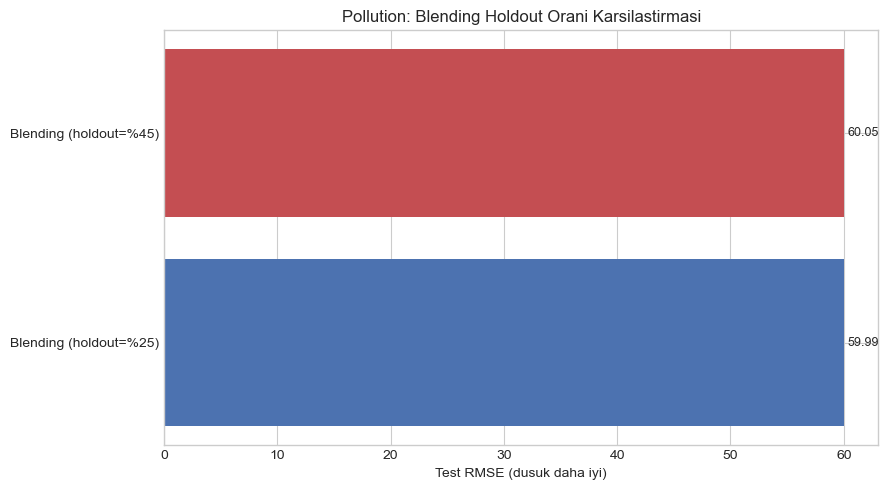

In [52]:
print("\n==== Egzersiz 4: Holdout Oranı ====")

# Blending (Holdout %45)
Xtr_pol_base45, Xtr_pol_hold45, ytr_pol_base45, ytr_pol_hold45 = train_test_split(
    Xtr_pol_s, ytr_pol, test_size=0.45, random_state=RANDOM_STATE
)
print(f"Blending -- {Xtr_pol_base45.shape}, holdout: {Xtr_pol_hold45.shape}")

# Blending (Holdout %25)
Xtr_pol_base25, Xtr_pol_hold25, ytr_pol_base25, ytr_pol_hold25 = train_test_split(
    Xtr_pol_s, ytr_pol, test_size=0.25, random_state=RANDOM_STATE
)
print(f"Blending -- {Xtr_pol_base25.shape}, holdout: {Xtr_pol_hold25.shape}")

# Blending (Holdout %25 ve %45) icin meta-egitim ve taban modelleri olusturalim
blend_meta_train_25 = pd.DataFrame(index=range(len(ytr_pol_hold25)))
blend_meta_train_45 = pd.DataFrame(index=range(len(ytr_pol_hold45)))
blend_base_models_25, blend_base_models_45 = {}, {}
for name, model_template in estimators_pol:
    model = type(model_template)(**model_template.get_params())
    model.fit(Xtr_pol_base45, ytr_pol_base45)
    blend_base_models_45[name] = model
    blend_meta_train_45[name] = model.predict(Xtr_pol_hold45)

    model.fit(Xtr_pol_base25, ytr_pol_base25)
    blend_base_models_25[name] = model
    blend_meta_train_25[name] = model.predict(Xtr_pol_hold25)

# Meta-modeli Ridge ile egitiyoruz
meta_blend_25 = Ridge(alpha=1.0)
meta_blend_25.fit(blend_meta_train_25, ytr_pol_hold25)

meta_blend_45 = Ridge(alpha=1.0)
meta_blend_45.fit(blend_meta_train_45, ytr_pol_hold45)

# TEST degerlendirmesi: taban modelleri tum egitim setinde yeniden egit (zaten fit edilmis
# durumdalar), OOF ile egitilmis meta-modeli, tabanlarin TEST tahminleriyle degerlendir.
blend_test_features_25 = pd.DataFrame({name: blend_base_models_25[name].predict(Xte_pol_s) for name in blend_base_models_25})
blend_test_features_45 = pd.DataFrame({name: blend_base_models_45[name].predict(Xte_pol_s) for name in blend_base_models_45})
pred_blend_25 = meta_blend_25.predict(blend_test_features_25)
pred_blend_45 = meta_blend_45.predict(blend_test_features_45)
blend_metrics25 = {'RMSE': rmse(yte_pol, pred_blend_25)}
blend_metrics45 = {'RMSE': rmse(yte_pol, pred_blend_45)}

reg_row = [
    {'Model': 'Blending (holdout=%25)', **blend_metrics25},
    {'Model': 'Blending (holdout=%45)', **blend_metrics45},
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([r['Model'] for r in reg_row], [r['RMSE'] for r in reg_row], color=['#4c72b0', '#c44e52'])
ax.set_xlabel('Test RMSE (dusuk daha iyi)')
ax.set_title('Pollution: Blending Holdout Orani Karsilastirmasi')
for i, v in enumerate([r['RMSE'] for r in reg_row]):
    ax.text(v + 0.3, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**E6.** Pollution veri setinde `StackingRegressor`'a `passthrough=True` parametresini ekleyin
(orijinal öznitelikleri de meta-öğreniciye vererek). Test RMSE değişiyor mu? Meta-öğrenici
(`Ridge`) katsayılarına bakıp orijinal özniteliklerden hangilerinin meta-modelde anlamlı ağırlık
aldığını inceleyin.

In [60]:
print("\n==== Egzersiz 6: Passthrough Parametresi ====")

stack_reg_true = StackingRegressor(
    estimators=estimators_pol, final_estimator=Ridge(alpha=1.0), cv=cv_pol, passthrough=True
)
stack_reg_true.fit(Xtr_pol_s, ytr_pol)
pred_sr_true = stack_reg_true.predict(Xte_pol_s)
stack_reg_true_metrics = {'RMSE': rmse(yte_pol, pred_sr_true), 'MAE': mean_absolute_error(yte_pol, pred_sr_true), 'R2': r2_score(yte_pol, pred_sr_true)}

print(f"Stacking Regressor (passthrough=True) -- TEST RMSE: {stack_reg_true_metrics['RMSE']:.2f}")
print(f"Stacking Regressor (passthrough=False) -- TEST RMSE: {stack_reg_metrics['RMSE']:.2f}")

# Meta-öğrenici katsayılarına inceleyelim
meta_coefs = stack_reg_true.final_estimator_.coef_
meta_features = list(stack_reg_true.named_estimators_.keys()) + list(Xtr_pol_s.columns)
meta_coef_df = pd.DataFrame({'Feature': meta_features, 'Coefficient': meta_coefs})
meta_coef_df = meta_coef_df.reindex(meta_coef_df['Coefficient'].abs().sort_values(ascending=False).index)

print("\n--- Meta-Model (Ridge) Katsayı Analizi ---")
print(meta_coef_df.to_string(index=False))

print("\nYORUM: Katsayılara bakarsak taban modellerimiz en son kısımlarda -1 ile 1 aralığında değişmiş yani Ridge bu tahminleri görmezden gelmiş. Bunun anlamı, meta-modelin taban modellerin tahminlerini kullanmak yerine orijinal 9 özelliği kullanmayı tercih ettiğidir. Bu durum, taban modellerin tahminlerinin meta-model için yeterince bilgilendirici olmadığını ve orijinal özelliklerin daha güçlü bir sinyal sağladığını gösterebilir. Bu nedenle, passthrough=True parametresi ile orijinal özellikleri meta-modelin eğitimine dahil etmek, model performansını artırabilir.")


==== Egzersiz 6: Passthrough Parametresi ====
Stacking Regressor (passthrough=True) -- TEST RMSE: 58.97
Stacking Regressor (passthrough=False) -- TEST RMSE: 59.03

--- Meta-Model (Ridge) Katsayı Analizi ---
Feature  Coefficient
   TEMP  -122.831723
   DEWP   100.272437
cbwd_SE    51.245417
cbwd_cv    45.417442
   PRES   -22.740516
     Ir   -16.601012
    Iws   -15.043981
  month    -6.434593
     Is    -5.545624
cbwd_NW    -2.253007
  ridge    -1.679753
     rf     1.014074
    knn     0.242267
   tree    -0.194820

YORUM: Katsayılara bakarsak taban modellerimiz en son kısımlarda -1 ile 1 aralığında değişmiş yani Ridge bu tahminleri görmezden gelmiş. Bunun anlamı, meta-modelin taban modellerin tahminlerini kullanmak yerine orijinal 9 özelliği kullanmayı tercih ettiğidir. Bu durum, taban modellerin tahminlerinin meta-model için yeterince bilgilendirici olmadığını ve orijinal özelliklerin daha güçlü bir sinyal sağladığını gösterebilir. Bu nedenle, passthrough=True parametresi ile oriji

## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Wolpert, D. H. (1992) — "Stacked Generalization", *Neural Networks*, 5(2), 241-259](https://doi.org/10.1016/S0893-6080(05)80023-1) | Stacking (§3) | Yığınlı genellemeyi tanımlayan temel makale |
| [scikit-learn — Ensemble methods: Voting Classifier/Regressor](https://scikit-learn.org/stable/modules/ensemble.html#voting-classifier) | Voting (§2, Adım 3-4, 10) | Resmi dokümantasyon |
| [scikit-learn — Ensemble methods: Stacked generalization](https://scikit-learn.org/stable/modules/ensemble.html#stacked-generalization) | Stacking (§3, Adım 7-8, 11) | `StackingClassifier`/`StackingRegressor` ve `cv`/`passthrough` parametreleri |
| [scikit-learn — `sklearn.model_selection.cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html) | Manuel OOF Stacking (Adım 7) | Out-of-fold tahmin üretiminin resmi API'si |
| [MLWave — Kaggle Ensembling Guide](https://mlwave.com/kaggle-ensembling-guide/) | Voting/Stacking/Blending pratikleri | Kaggle yarışmalarında yaygın kullanılan, iyi bilinen pratik rehber |
| [Netflix Prize — BellKor's Pragmatic Chaos, final rapor (2009)](https://www.netflixprize.com/assets/GrandPrize2009_BPC_BellKor.pdf) | Endüstri örneği (§1, §3, §4) | Blending/stacking'in en bilinen büyük ölçekli uygulaması |
| [UCI ML Repository — ELENA Project / Phoneme veri seti bilgisi (OpenML #1489 aynası)](https://www.openml.org/d/1489) | Adım 1-5 verisi | Orijinal akademik kaynak; bu notebook'ta `jbrownlee/Datasets` GitHub aynasından indirildi |
| [Kleiber, C. & Zeileis, A. — *Applied Econometrics with R*, Springer (2008), `AER::CreditCard`](https://cran.r-project.org/package=AER) | Adım 6-8 verisi | CRAN paket dokümantasyonu; veri Greene (2003) *Econometric Analysis*'ten |
| [Liang, X. ve ark. (2015) — "Assessing Beijing's PM2.5 pollution", *Proc. R. Soc. A*, 471(2182)](https://doi.org/10.1098/rspa.2015.0257) | Adım 9-11 verisi | UCI ML Repository "Beijing PM2.5 Data Set" |
| [caretEnsemble — CRAN paket dokümantasyonu](https://cran.r-project.org/package=caretEnsemble) | R Uygulaması | `caretList` + `caretStack` ile R'da stacking |
| [DuckDB — SQL dokümantasyonu](https://duckdb.org/docs/) | SQL Uygulaması | Pencere fonksiyonları, `JOIN`, `GROUP BY` sözdizimi |